
# 07 - Comparación de intervalos de predicción

Este notebook compara, sobre el conjunto de validación (2024), los intervalos de predicción obtenidos en los notebooks anteriores:

- Modelo base ingenuo estacional + split conformal (`06a_split_conformal_baseline.ipynb`)
- Regresión lineal + CQR con MAPIE (`06b_cqr_supervised_models.ipynb`)
- LightGBM + CQR con MAPIE (`06b_cqr_supervised_models.ipynb`)
- CatBoost + CQR con MAPIE (`06b_cqr_supervised_models.ipynb`)

Y, por otra parte, genera:

1. Métricas de los intervalos de predicción usando todas las predicciones disponibles
2. Métricas de los intervalos de predicción restringidas a los instantes objetivo que son comunes a todos los métodos
3. Tablas comparativas y una selección preliminar del mejor método por horizonte
4. Figuras relevantes que muestren claramente la comparación buscada.


## Criterio de comparación

La comparación principal del notebook se realizará sobre los instantes objetivo comunes a todos los métodos para cada horizonte. De esta manera, se evita comparar intervalos calculados sobre subconjuntos distintos de observaciones.

Se evaluarán las siguientes métricas, tal y como se ha establecido en la memoria:

- Cobertura empírica
- Aanchura media
- Interval score

In [16]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display


In [17]:
# Configuración general del notebook
# ==============================================================================
# El notebook puede ejecutarse desde la carpeta notebooks/ o desde la raíz del
# repositorio. Esta función localiza la raíz de forma dinámica.

def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual.

    Esta función evita depender de rutas absolutas locales. Así, el notebook puede
    ejecutarse aunque el repositorio esté guardado en otra carpeta o se abra desde
    un directorio diferente dentro del proyecto.
    """
    current = Path.cwd() if start is None else start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "reports").exists():
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto. Debe ejecutarse el notebook desde "
        "la raíz del repositorio o desde la carpeta notebooks/."
    )

PROJECT_ROOT = find_project_root()
REPORTS_INTERVALS_DIR = PROJECT_ROOT / "reports" / "intervals"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

for path in [REPORTS_TABLES_DIR, REPORTS_FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

HORIZONS: List[int] = [1, 4, 12, 24]
VALIDATION_SPLIT = "validation"
ALPHA = 0.20
NOMINAL_COVERAGE = 1 - ALPHA
EXAMPLE_HORIZON = 24
EXAMPLE_HOURS = 7 * 24  # una semana continua para la figura de ejemplo

MODEL_REGISTRY: Dict[str, Dict[str, str]] = {
    "baseline_seasonal_naive": {
        "display_name": "Modelo base ingenuo estacional",
        "short_name": "Baseline",
        "interval_prefix": "split_conformal_baseline",
        "method": "split_conformal",
        "method_display": "Split conformal",
        "label": "Baseline + split conformal",
        "color": "tab:gray",
    },
    "linear_regression": {
        "display_name": "Regresión lineal",
        "short_name": "Lineal",
        "interval_prefix": "cqr_linear_regression",
        "method": "cqr_mapie",
        "method_display": "CQR",
        "label": "Regresión lineal + CQR",
        "color": "tab:green",
    },
    "lightgbm": {
        "display_name": "LightGBM",
        "short_name": "LGBM",
        "interval_prefix": "cqr_lightgbm",
        "method": "cqr_mapie",
        "method_display": "CQR",
        "label": "LightGBM + CQR",
        "color": "tab:red",
    },
    "catboost": {
        "display_name": "CatBoost",
        "short_name": "CAT",
        "interval_prefix": "cqr_catboost",
        "method": "cqr_mapie",
        "method_display": "CQR",
        "label": "CatBoost + CQR",
        "color": "tab:purple",
    },
}

MODEL_ORDER = list(MODEL_REGISTRY.keys())
HORIZON_MARKERS = {1: "o", 4: "s", 12: "^", 24: "D"}

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Intervalos: {REPORTS_INTERVALS_DIR}")
print(f"Tablas: {REPORTS_TABLES_DIR}")
print(f"Figuras: {REPORTS_FIGURES_DIR}")
print(f"Cobertura nominal: {NOMINAL_COVERAGE:.0%}")


Raíz del proyecto: c:\trabajo_github
Intervalos: c:\trabajo_github\reports\intervals
Tablas: c:\trabajo_github\reports\tables
Figuras: c:\trabajo_github\reports\figures
Cobertura nominal: 80%


In [18]:

def interval_score(
    y_true: pd.Series | np.ndarray,
    lower: pd.Series | np.ndarray,
    upper: pd.Series | np.ndarray,
    alpha: float,
) -> np.ndarray:
    """Calcula el interval score para los intervalos centrales."""
    y = np.asarray(y_true, dtype=float)
    l = np.asarray(lower, dtype=float)
    u = np.asarray(upper, dtype=float)

    width = u - l
    lower_penalty = (2 / alpha) * (l - y) * (y < l)
    upper_penalty = (2 / alpha) * (y - u) * (y > u)

    return width + lower_penalty + upper_penalty


def standardize_interval_frame(df: pd.DataFrame, model_id: str, horizon: int) -> pd.DataFrame:
    meta = MODEL_REGISTRY[model_id]
    out = df.copy()

    if "origin_timestamp" in out.columns:
        out["origin_timestamp"] = pd.to_datetime(out["origin_timestamp"])
    if "target_timestamp" in out.columns:
        out["target_timestamp"] = pd.to_datetime(out["target_timestamp"])

    out["model"] = model_id
    out["model_display"] = meta["display_name"]
    out["method"] = meta["method"]
    out["method_display"] = meta["method_display"]
    out["label"] = meta["label"]
    out["short_name"] = meta["short_name"]
    out["color"] = meta["color"]
    out["horizon"] = horizon

    out["split"] = VALIDATION_SPLIT

    out["interval_width"] = out["upper"] - out["lower"]

    out["covered"] = (out["y_true"] >= out["lower"]) & (out["y_true"] <= out["upper"])

    out["miss_lower"] = out["y_true"] < out["lower"]

    out["miss_upper"] = out["y_true"] > out["upper"]

    out["interval_score"] = interval_score(out["y_true"], out["lower"], out["upper"], ALPHA)

    # Columna unificada de predicción puntual de referencia para la figura de ejemplo.
    point_candidates = [
        "y_pred_reference",
        "y_pred_point",
        "y_pred",
        "y_pred_mapie",
        "y_pred_quantile_median",
    ]
    selected_point_col = None
    for candidate in point_candidates:
        if candidate in out.columns:
            selected_point_col = candidate
            break

    if selected_point_col is not None:
        out["y_pred_reference"] = out[selected_point_col]
    else:
        out["y_pred_reference"] = np.nan

    required = ["target_timestamp", "y_true", "lower", "upper"]
    missing = [col for col in required if col not in out.columns]
    if missing:
        raise ValueError(f"Faltan columnas requeridas en {model_id}, h={horizon}: {missing}")

    return out


def compute_interval_metrics(df: pd.DataFrame) -> dict:
    """Resume las métricas de intervalos."""

    coverage = float(df["covered"].mean())
    return {
        "model": df["model"].iloc[0],
        "model_display": df["model_display"].iloc[0],
        "method": df["method"].iloc[0],
        "method_display": df["method_display"].iloc[0],
        "label": df["label"].iloc[0],
        "horizon": int(df["horizon"].iloc[0]),
        "alpha": ALPHA,
        "nominal_coverage": NOMINAL_COVERAGE,
        "n_samples": int(len(df)),
        "empirical_coverage": coverage,
        "coverage_error": coverage - NOMINAL_COVERAGE,
        "coverage_abs_error": abs(coverage - NOMINAL_COVERAGE),
        "mean_width": float(df["interval_width"].mean()),
        "median_width": float(df["interval_width"].median()),
        "mean_interval_score": float(df["interval_score"].mean()),
        "median_interval_score": float(df["interval_score"].median()),
        "miss_lower_rate": float(df["miss_lower"].mean()),
        "miss_upper_rate": float(df["miss_upper"].mean()),
        "target_start": df["target_timestamp"].min(),
        "target_end": df["target_timestamp"].max(),
    }


def select_continuous_block(df: pd.DataFrame, n_hours: int) -> pd.DataFrame:
    """Selecciona el primer bloque continuo de `n_hours`; si no existe, usa el mayor."""
    work = df.sort_values("target_timestamp").copy()
    work["delta_h"] = work["target_timestamp"].diff() / pd.Timedelta(hours=1)
    work["block_id"] = (work["delta_h"].isna() | (work["delta_h"] != 1)).cumsum()

    summary = (
        work.groupby("block_id")
        .agg(
            start=("target_timestamp", "min"),
            end=("target_timestamp", "max"),
            n_hours=("target_timestamp", "count"),
        )
        .reset_index()
    )

    candidates = summary.loc[summary["n_hours"] >= n_hours]

    if candidates.empty:
        block_id = summary.sort_values(["n_hours", "start"], ascending=[False, True]).iloc[0]["block_id"]
        print(
            f"No se encontró un bloque continuo de {n_hours} horas. "
            "Se utilizará el bloque continuo más largo disponible."
        )
    else:
        block_id = candidates.sort_values("start").iloc[0]["block_id"]

    selected = work.loc[work["block_id"] == block_id].copy().head(n_hours)
    return selected.drop(columns=["delta_h", "block_id"], errors="ignore").reset_index(drop=True)



## Carga y estandarización de los intervalos

Se cargan los archivos `.parquet` generados por los notebooks `06a_split_conformal_baseline` y `06b_cqr_suprevised_models`. Después, se armonizarán sus columnas para construir una sola tabla.


In [19]:

# Carga de los archivos con la información de los intervalos

interval_frames = []
loaded_files = []

for model_id in MODEL_ORDER:
    meta = MODEL_REGISTRY[model_id]

    for horizon in HORIZONS:
        path = REPORTS_INTERVALS_DIR / f"{meta['interval_prefix']}_h{horizon:02d}.parquet"

        if not path.exists():
            raise FileNotFoundError(
                f"No se ha encontrado {path}. Ejecuta antes los notebooks 06a y 06b."
            )

        df_h = pd.read_parquet(path)
        df_h = standardize_interval_frame(df_h, model_id=model_id, horizon=horizon)
        interval_frames.append(df_h)
        loaded_files.append({"model": model_id, "horizon": horizon, "path": str(path), "n_rows": len(df_h)})

all_intervals = pd.concat(interval_frames, ignore_index=True)
all_intervals = all_intervals.sort_values(["horizon", "model", "target_timestamp"]).reset_index(drop=True)
loaded_files_df = pd.DataFrame(loaded_files)

# Se trabaja únicamente con validación externa
validation_intervals = all_intervals.loc[all_intervals["split"] == VALIDATION_SPLIT].copy()
validation_intervals = validation_intervals.sort_values(["horizon", "model", "target_timestamp"]).reset_index(drop=True)

# Comprobación de duplicados
duplicated_counts = (
    validation_intervals.groupby(["model", "horizon", "target_timestamp"]).size().reset_index(name="n")
)
max_dup = int(duplicated_counts["n"].max())
assert max_dup == 1, "Existen instantes objetivo duplicados para algún método."

print(f"Archivos cargados: {len(loaded_files_df)}")
print(f"Intervalos totales en validación: {len(validation_intervals):,}")
display(loaded_files_df)
validation_intervals.head()


Archivos cargados: 16
Intervalos totales en validación: 134,304


,model,horizon,path,n_rows
0,baseline_seasonal_naive,1,c:\trabajo_github\reports\intervals\split_conf...,8265
1,baseline_seasonal_naive,4,c:\trabajo_github\reports\intervals\split_conf...,8265
2,baseline_seasonal_naive,12,c:\trabajo_github\reports\intervals\split_conf...,8265
3,baseline_seasonal_naive,24,c:\trabajo_github\reports\intervals\split_conf...,8265
4,linear_regression,1,c:\trabajo_github\reports\intervals\cqr_linear...,8437
5,linear_regression,4,c:\trabajo_github\reports\intervals\cqr_linear...,8437
6,linear_regression,12,c:\trabajo_github\reports\intervals\cqr_linear...,8437
7,linear_regression,24,c:\trabajo_github\reports\intervals\cqr_linear...,8437
8,lightgbm,1,c:\trabajo_github\reports\intervals\cqr_lightg...,8437
9,lightgbm,4,c:\trabajo_github\reports\intervals\cqr_lightg...,8437


,horizon,split,origin_timestamp,target_timestamp,y_true,y_pred,model,baseline_rule,baseline_source_timestamp,source_lag_from_origin_h,is_evaluable,residual,abs_error,squared_error,model_display,method,alpha,nominal_coverage,q_hat,lower,upper,interval_width,covered,miss_lower,miss_upper,interval_score,method_display,label,short_name,color,y_pred_reference,lower_quantile,upper_quantile,q_level,y_pred_quantile_median,y_pred_mapie,lower_prelim,upper_prelim,raw_interval_width,y_pred_point
0,1,validation,2023-12-31 23:00:00,2024-01-01 00:00:00,5.000,5.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 00:00:00,23.000,True,0.000,0.000,0.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-22.000,32.000,54.000,True,False,False,54.000,Split conformal,Baseline + split conformal,Baseline,tab:gray,5.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,validation,2024-01-01 00:00:00,2024-01-01 01:00:00,10.000,9.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 01:00:00,23.000,True,1.000,1.000,1.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-18.000,36.000,54.000,True,False,False,54.000,Split conformal,Baseline + split conformal,Baseline,tab:gray,9.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,validation,2024-01-01 01:00:00,2024-01-01 02:00:00,6.000,17.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 02:00:00,23.000,True,-11.000,11.000,121.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-10.000,44.000,54.000,True,False,False,54.000,Split conformal,Baseline + split conformal,Baseline,tab:gray,17.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,validation,2024-01-01 02:00:00,2024-01-01 03:00:00,2.000,17.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 03:00:00,23.000,True,-15.000,15.000,225.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-10.000,44.000,54.000,True,False,False,54.000,Split conformal,Baseline + split conformal,Baseline,tab:gray,17.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,validation,2024-01-01 03:00:00,2024-01-01 04:00:00,2.000,15.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 04:00:00,23.000,True,-13.000,13.000,169.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-12.000,42.000,54.000,True,False,False,54.000,Split conformal,Baseline + split conformal,Baseline,tab:gray,15.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



## Disponibilidad de las predicciones y de los instantes objetivo comunes

El modelo base y los modelos supervisados no tienen exactamente el mismo número de predicciones evaluables. Por este motivo, se construirán dos tablas:

- Una que informe del número de intervalos disponibles por horizonte
- Una segunda que intersecte los `target_timestamp` entre todos los métodos.


In [20]:

# Disponibilidad y conjunto común de instantes objetivo

availability_rows = []
common_target_rows = []
common_frames = []

for horizon in HORIZONS:
    subset_h = validation_intervals.loc[validation_intervals["horizon"] == horizon].copy()

    target_sets = {}
    for model_id in MODEL_ORDER:
        model_df = subset_h.loc[subset_h["model"] == model_id].copy()
        target_set = set(model_df["target_timestamp"])
        target_sets[model_id] = target_set

        availability_rows.append(
            {
                "horizon": horizon,
                "model": model_id,
                "model_display": MODEL_REGISTRY[model_id]["display_name"],
                "method": MODEL_REGISTRY[model_id]["method"],
                "label": MODEL_REGISTRY[model_id]["label"],
                "n_available": int(len(model_df)),
                "target_start": model_df["target_timestamp"].min(),
                "target_end": model_df["target_timestamp"].max(),
            }
        )

    common_targets = sorted(set.intersection(*target_sets.values()))

    common_target_rows.append(
        {
            "horizon": horizon,
            "n_common_targets": int(len(common_targets)),
            "common_target_start": common_targets[0] if common_targets else pd.NaT,
            "common_target_end": common_targets[-1] if common_targets else pd.NaT,
        }
    )

    for model_id in MODEL_ORDER:
        model_common = subset_h.loc[
            (subset_h["model"] == model_id)
            & (subset_h["target_timestamp"].isin(common_targets))
        ].copy()
        common_frames.append(model_common)

availability_df = pd.DataFrame(availability_rows).sort_values(["horizon", "model"]).reset_index(drop=True)
common_target_counts_df = pd.DataFrame(common_target_rows).sort_values("horizon").reset_index(drop=True)
common_intervals = pd.concat(common_frames, ignore_index=True)
common_intervals = common_intervals.sort_values(["horizon", "model", "target_timestamp"]).reset_index(drop=True)

# Tabla resumen con la disponibilidad y el tamaño del conjunto común.
comparison_target_counts_df = availability_df.merge(common_target_counts_df, on="horizon", how="left")
comparison_target_counts_df["pct_common_over_available"] = (
    100 * comparison_target_counts_df["n_common_targets"] / comparison_target_counts_df["n_available"]
)

print("Disponibilidad de predicciones por método y horizonte:")
display(comparison_target_counts_df)

print("Instantes comunes por horizonte:")
display(common_target_counts_df)


Disponibilidad de predicciones por método y horizonte:


,horizon,model,model_display,method,label,n_available,target_start,target_end,n_common_targets,common_target_start,common_target_end,pct_common_over_available
0,1,baseline_seasonal_naive,Modelo base ingenuo estacional,split_conformal,Baseline + split conformal,8265,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,100.000
1,1,catboost,CatBoost,cqr_mapie,CatBoost + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
2,1,lightgbm,LightGBM,cqr_mapie,LightGBM + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
3,1,linear_regression,Regresión lineal,cqr_mapie,Regresión lineal + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
4,4,baseline_seasonal_naive,Modelo base ingenuo estacional,split_conformal,Baseline + split conformal,8265,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,100.000
5,4,catboost,CatBoost,cqr_mapie,CatBoost + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
6,4,lightgbm,LightGBM,cqr_mapie,LightGBM + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
7,4,linear_regression,Regresión lineal,cqr_mapie,Regresión lineal + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
8,12,baseline_seasonal_naive,Modelo base ingenuo estacional,split_conformal,Baseline + split conformal,8265,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,100.000
9,12,catboost,CatBoost,cqr_mapie,CatBoost + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961


Instantes comunes por horizonte:


,horizon,n_common_targets,common_target_start,common_target_end
0,1,8265,2024-01-01,2024-12-31 23:00:00
1,4,8265,2024-01-01,2024-12-31 23:00:00
2,12,8265,2024-01-01,2024-12-31 23:00:00
3,24,8265,2024-01-01,2024-12-31 23:00:00



## Métricas de los intervalos

Se calculan dos versiones de la comparación:

1. `available_metrics_df`: usa todas las predicciones disponibles para cada modelo.
2. `common_metrics_df`: usa solo los instantes objetivo comunes a todos los modelos, por lo que servirá como comparativa principal.


In [21]:

# Cálculo de métricas para todas las observaciones disponibles

available_metric_rows = []
for (model_id, horizon), group in validation_intervals.groupby(["model", "horizon"], sort=True):
    available_metric_rows.append(compute_interval_metrics(group))

available_metrics_df = pd.DataFrame(available_metric_rows).sort_values(["horizon", "model"]).reset_index(drop=True)

# Cálculo de métricas para los instantes objetivo comunes
common_metric_rows = []
for (model_id, horizon), group in common_intervals.groupby(["model", "horizon"], sort=True):
    common_metric_rows.append(compute_interval_metrics(group))

common_metrics_df = pd.DataFrame(common_metric_rows).sort_values(["horizon", "model"]).reset_index(drop=True)

# Ranking por horizonte, usando como criterio principal el interval score.
ranked_frames = []
for horizon, group in common_metrics_df.groupby("horizon", sort=True):
    ranked = group.sort_values(
        ["mean_interval_score", "coverage_abs_error", "mean_width"],
        ascending=[True, True, True],
    ).copy()
    ranked["rank_interval_score"] = np.arange(1, len(ranked) + 1)
    ranked_frames.append(ranked)

common_metrics_df = pd.concat(ranked_frames, ignore_index=True).sort_values(["horizon", "rank_interval_score"]).reset_index(drop=True)

# Selección preliminar del mejor método por horizonte.
best_method_by_horizon_df = (
    common_metrics_df.sort_values(["horizon", "rank_interval_score"]).groupby("horizon", as_index=False).first()
)

# Tabla de las mejoras respecto al modelo base en la comparación principal.
baseline_reference = (
    common_metrics_df.loc[common_metrics_df["model"] == "baseline_seasonal_naive", ["horizon", "empirical_coverage", "mean_width", "mean_interval_score"]]
    .rename(
        columns={
            "empirical_coverage": "baseline_coverage",
            "mean_width": "baseline_mean_width",
            "mean_interval_score": "baseline_mean_interval_score",
        }
    )
)

improvement_vs_baseline_df = common_metrics_df.merge(baseline_reference, on="horizon", how="left")
improvement_vs_baseline_df = improvement_vs_baseline_df.loc[
    improvement_vs_baseline_df["model"] != "baseline_seasonal_naive"
].copy()
improvement_vs_baseline_df["delta_coverage_vs_baseline"] = (
    improvement_vs_baseline_df["empirical_coverage"] - improvement_vs_baseline_df["baseline_coverage"]
)
improvement_vs_baseline_df["width_reduction_vs_baseline"] = (
    improvement_vs_baseline_df["baseline_mean_width"] - improvement_vs_baseline_df["mean_width"]
)
improvement_vs_baseline_df["interval_score_reduction_vs_baseline"] = (
    improvement_vs_baseline_df["baseline_mean_interval_score"] - improvement_vs_baseline_df["mean_interval_score"]
)
improvement_vs_baseline_df = improvement_vs_baseline_df.sort_values(["horizon", "rank_interval_score"]).reset_index(drop=True)

summary_common_df = common_metrics_df[
    [
        "horizon",
        "label",
        "n_samples",
        "empirical_coverage",
        "mean_width",
        "mean_interval_score",
        "rank_interval_score",
    ]
].copy()

common_metrics_wide_df = summary_common_df.pivot(index="horizon", columns="label")

print("Métricas de intervalos sobre todas las observaciones disponibles:")
display(available_metrics_df[["horizon", "label", "n_samples", "empirical_coverage", "mean_width", "mean_interval_score"]])

print("Métricas de intervalos sobre instantes objetivo comunes (comparación principal):")
display(common_metrics_df[["horizon", "label", "n_samples", "empirical_coverage", "mean_width", "mean_interval_score", "rank_interval_score"]])

print("Selección preliminar del mejor método por horizonte:")
display(best_method_by_horizon_df[["horizon", "label", "empirical_coverage", "mean_width", "mean_interval_score"]])


Métricas de intervalos sobre todas las observaciones disponibles:


,horizon,label,n_samples,empirical_coverage,mean_width,mean_interval_score
0,1,Baseline + split conformal,8265,0.800,54.000,79.195
1,1,CatBoost + CQR,8437,0.803,19.732,29.626
2,1,LightGBM + CQR,8437,0.801,19.679,29.827
3,1,Regresión lineal + CQR,8437,0.804,21.550,32.387
4,4,Baseline + split conformal,8265,0.800,54.000,79.195
5,4,CatBoost + CQR,8437,0.790,35.821,49.702
6,4,LightGBM + CQR,8437,0.796,37.045,50.627
7,4,Regresión lineal + CQR,8437,0.798,40.958,54.960
8,12,Baseline + split conformal,8265,0.800,54.000,79.195
9,12,CatBoost + CQR,8437,0.795,41.977,57.325


Métricas de intervalos sobre instantes objetivo comunes (comparación principal):


,horizon,label,n_samples,empirical_coverage,mean_width,mean_interval_score,rank_interval_score
0,1,CatBoost + CQR,8265,0.802,19.759,29.740,1
1,1,LightGBM + CQR,8265,0.799,19.687,29.961,2
2,1,Regresión lineal + CQR,8265,0.803,21.547,32.482,3
3,1,Baseline + split conformal,8265,0.800,54.000,79.195,4
4,4,CatBoost + CQR,8265,0.790,35.902,49.886,1
5,4,LightGBM + CQR,8265,0.795,37.052,50.826,2
6,4,Regresión lineal + CQR,8265,0.797,40.986,55.085,3
7,4,Baseline + split conformal,8265,0.800,54.000,79.195,4
8,12,CatBoost + CQR,8265,0.796,42.207,57.559,1
9,12,LightGBM + CQR,8265,0.792,42.944,58.315,2


Selección preliminar del mejor método por horizonte:


,horizon,label,empirical_coverage,mean_width,mean_interval_score
0,1,CatBoost + CQR,0.802,19.759,29.740
1,4,CatBoost + CQR,0.790,35.902,49.886
2,12,CatBoost + CQR,0.796,42.207,57.559
3,24,CatBoost + CQR,0.779,43.010,59.237


In [22]:

# Guardado de tablas

metrics_available_path = REPORTS_TABLES_DIR / "interval_metrics_validation_available.csv"
metrics_common_path = REPORTS_TABLES_DIR / "interval_metrics_validation_common.csv"
metrics_common_wide_path = REPORTS_TABLES_DIR / "interval_metrics_validation_common_wide.csv"
best_method_path = REPORTS_TABLES_DIR / "interval_best_method_by_horizon.csv"
improvement_path = REPORTS_TABLES_DIR / "interval_improvement_vs_baseline.csv"
counts_path = REPORTS_TABLES_DIR / "interval_comparison_target_counts.csv"

available_metrics_df.to_csv(metrics_available_path, index=False)
common_metrics_df.to_csv(metrics_common_path, index=False)
common_metrics_wide_df.to_csv(metrics_common_wide_path)
best_method_by_horizon_df.to_csv(best_method_path, index=False)
improvement_vs_baseline_df.to_csv(improvement_path, index=False)
comparison_target_counts_df.to_csv(counts_path, index=False)

for path in [
    metrics_available_path,
    metrics_common_path,
    metrics_common_wide_path,
    best_method_path,
    improvement_path,
    counts_path,
]:
    print(f"Tabla guardada: {path}")


Tabla guardada: c:\trabajo_github\reports\tables\interval_metrics_validation_available.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_metrics_validation_common.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_metrics_validation_common_wide.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_best_method_by_horizon.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_improvement_vs_baseline.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_comparison_target_counts.csv



## Figuras comparativas

Las siguientes figuras sintetizan las diversas comparaciones realizadas.


Figura guardada en: c:\trabajo_github\reports\figures\fig_interval_metrics_validation_common.png


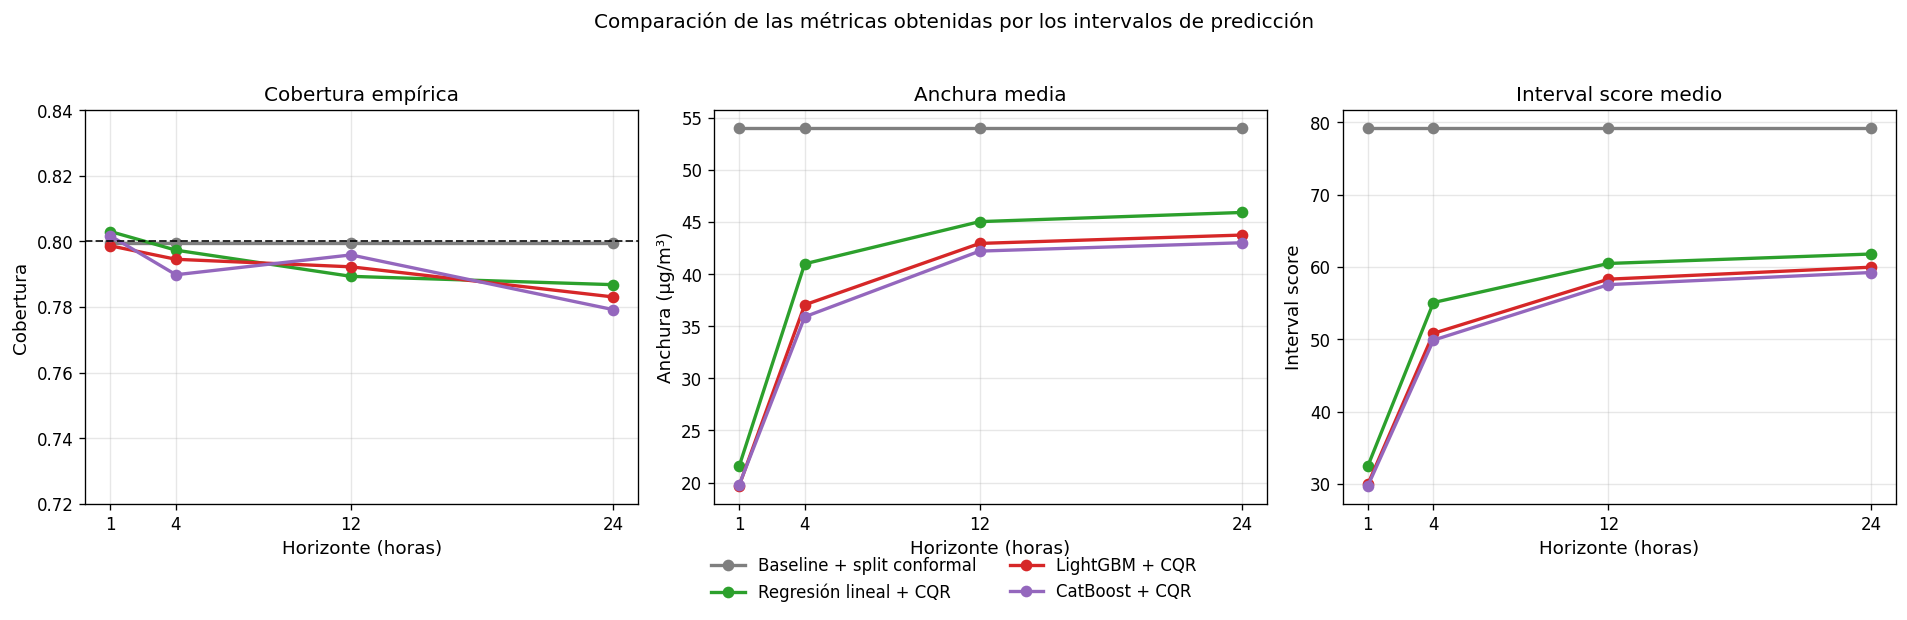

In [23]:

# Figura 1: métricas principales que involucran a los instantes objetivo comunes

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True)
plot_df = common_metrics_df.copy()

for model_id in MODEL_ORDER:
    model_df = plot_df.loc[plot_df["model"] == model_id].sort_values("horizon")
    meta = MODEL_REGISTRY[model_id]

    axes[0].plot(
        model_df["horizon"],
        model_df["empirical_coverage"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=meta["color"],
        label=meta["label"],
    )
    axes[1].plot(
        model_df["horizon"],
        model_df["mean_width"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=meta["color"],
        label=meta["label"],
    )
    axes[2].plot(
        model_df["horizon"],
        model_df["mean_interval_score"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=meta["color"],
        label=meta["label"],
    )

axes[0].axhline(NOMINAL_COVERAGE, linestyle="--", linewidth=1.2, color="black", alpha=0.8)
axes[0].set_title("Cobertura empírica")
axes[0].set_ylabel("Cobertura")
axes[0].set_ylim(0.72, max(0.84, plot_df["empirical_coverage"].max() + 0.01))

axes[1].set_title("Anchura media")
axes[1].set_ylabel("Anchura (µg/m³)")

axes[2].set_title("Interval score medio")
axes[2].set_ylabel("Interval score")

for ax in axes:
    ax.set_xlabel("Horizonte (horas)")
    ax.set_xticks(HORIZONS)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Comparación de las métricas obtenidas por los intervalos de predicción", y=1.03)
fig.tight_layout(rect=[0, 0.05, 1, 1])

figure_path = REPORTS_FIGURES_DIR / "fig_interval_metrics_validation_common.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {figure_path}")
plt.show()


Figura guardada en: c:\trabajo_github\reports\figures\fig_interval_tradeoff_validation_common.png


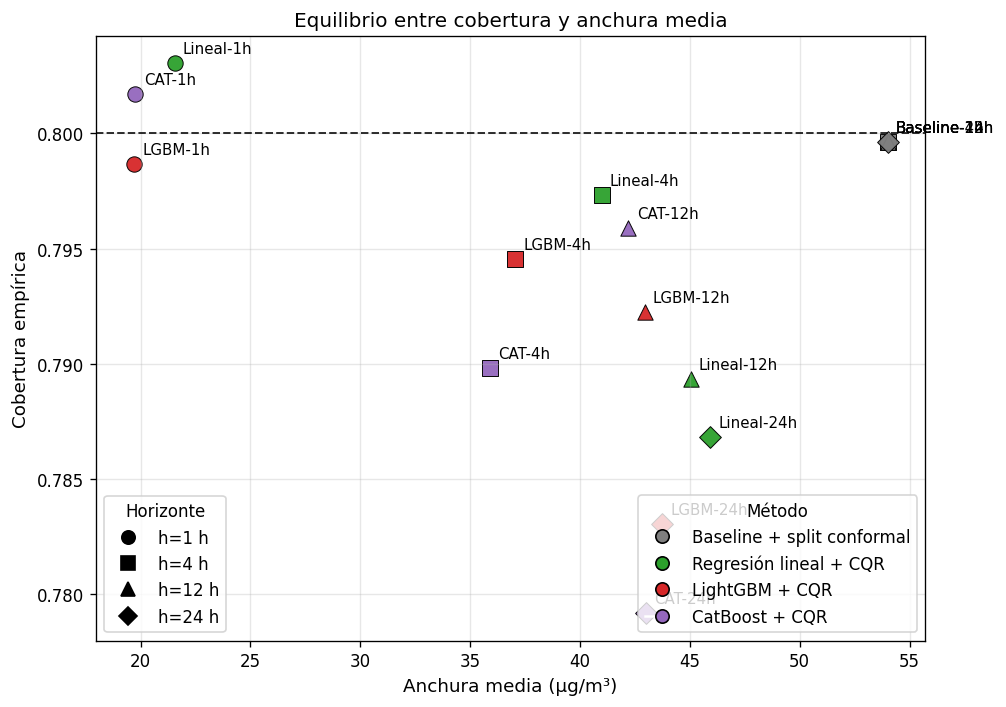

In [24]:

# Figura 2: equilibrio entre cobertura y anchura media

fig, ax = plt.subplots(figsize=(8.5, 6))
plot_df = common_metrics_df.copy()

for model_id in MODEL_ORDER:
    model_df = plot_df.loc[plot_df["model"] == model_id].sort_values("horizon")
    color = MODEL_REGISTRY[model_id]["color"]
    short_name = MODEL_REGISTRY[model_id]["short_name"]

    for _, row in model_df.iterrows():
        horizon = int(row["horizon"])
        marker = HORIZON_MARKERS[horizon]
        ax.scatter(
            row["mean_width"],
            row["empirical_coverage"],
            s=85,
            color=color,
            marker=marker,
            alpha=0.95,
            edgecolor="black",
            linewidth=0.6,
        )
        ax.annotate(
            f"{short_name}-{horizon}h",
            xy=(row["mean_width"], row["empirical_coverage"]),
            xytext=(5, 6),
            textcoords="offset points",
            fontsize=9,
        )

ax.axhline(NOMINAL_COVERAGE, linestyle="--", linewidth=1.2, color="black", alpha=0.8)
ax.set_title("Equilibrio entre cobertura y anchura media")
ax.set_xlabel("Anchura media (µg/m³)")
ax.set_ylabel("Cobertura empírica")
ax.grid(True, alpha=0.3)

model_legend = [
    Line2D([0], [0], marker="o", color="w", label=MODEL_REGISTRY[m]["label"], markerfacecolor=MODEL_REGISTRY[m]["color"], markeredgecolor="black", markersize=8)
    for m in MODEL_ORDER
]

horizon_legend = [
    Line2D([0], [0], marker=HORIZON_MARKERS[h], color="black", linestyle="", label=f"h={h} h", markersize=8)
    for h in HORIZONS
]

legend1 = ax.legend(handles=model_legend, loc="lower right", frameon=True, title="Método")
ax.add_artist(legend1)
ax.legend(handles=horizon_legend, loc="lower left", frameon=True, title="Horizonte")

tradeoff_path = REPORTS_FIGURES_DIR / "fig_interval_tradeoff_validation_common.png"
fig.tight_layout()
fig.savefig(tradeoff_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {tradeoff_path}")
plt.show()


Figura guardada en: c:\trabajo_github\reports\figures\fig_interval_improvement_vs_baseline_validation_common.png


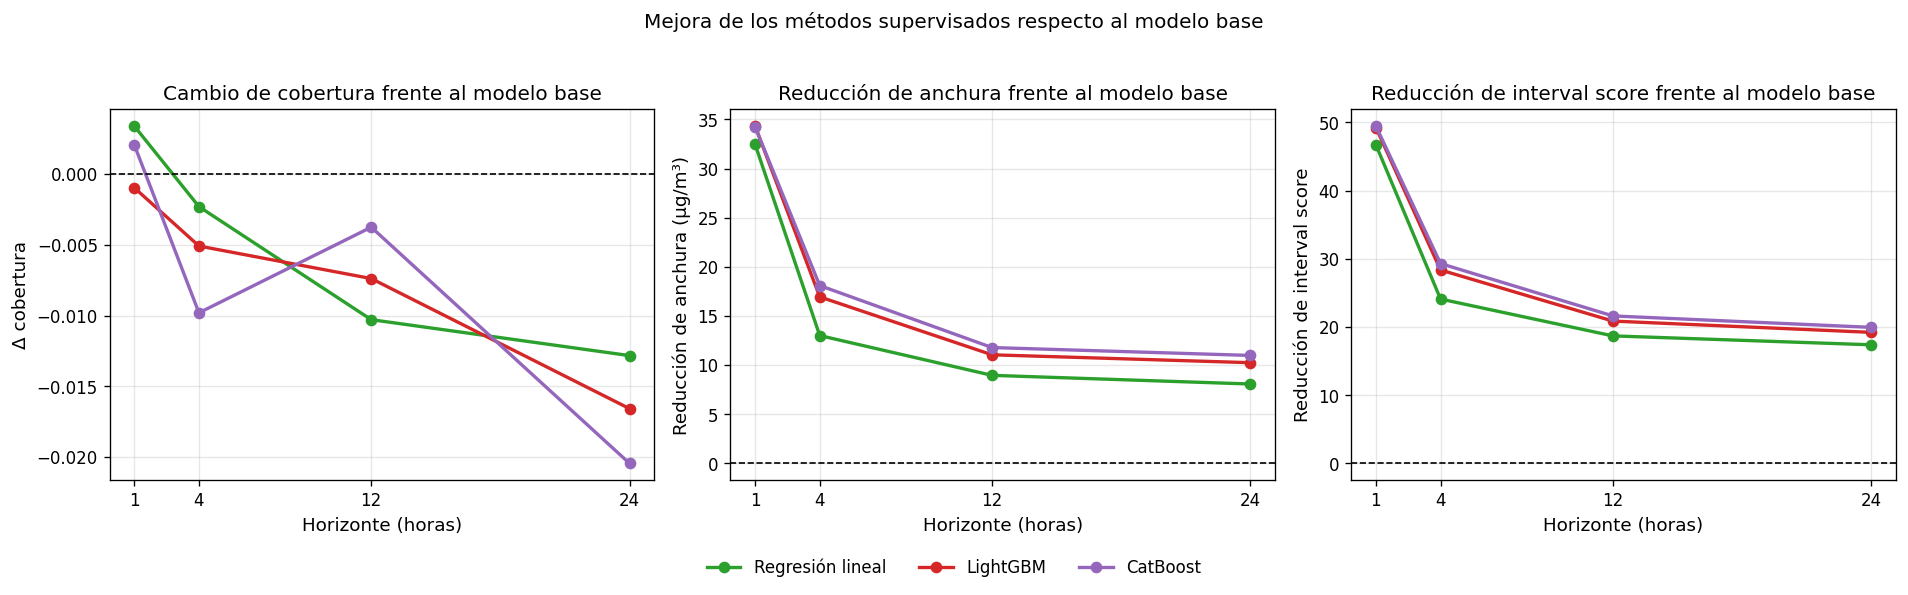

In [25]:

# Figura 3: mejora respecto al modelo base
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True)
plot_df = improvement_vs_baseline_df.copy()
non_baseline_models = [m for m in MODEL_ORDER if m != "baseline_seasonal_naive"]

for model_id in non_baseline_models:
    model_df = plot_df.loc[plot_df["model"] == model_id].sort_values("horizon")
    meta = MODEL_REGISTRY[model_id]

    axes[0].plot(
        model_df["horizon"],
        model_df["delta_coverage_vs_baseline"],
        marker="o",
        linewidth=2,
        color=meta["color"],
        label=meta["display_name"],
    )
    axes[1].plot(
        model_df["horizon"],
        model_df["width_reduction_vs_baseline"],
        marker="o",
        linewidth=2,
        color=meta["color"],
        label=meta["display_name"],
    )
    axes[2].plot(
        model_df["horizon"],
        model_df["interval_score_reduction_vs_baseline"],
        marker="o",
        linewidth=2,
        color=meta["color"],
        label=meta["display_name"],
    )

axes[0].axhline(0, linestyle="--", color="black", linewidth=1)
axes[0].set_title("Cambio de cobertura frente al modelo base")
axes[0].set_ylabel("Δ cobertura")

axes[1].axhline(0, linestyle="--", color="black", linewidth=1)
axes[1].set_title("Reducción de anchura frente al modelo base")
axes[1].set_ylabel("Reducción de anchura (µg/m³)")

axes[2].axhline(0, linestyle="--", color="black", linewidth=1)
axes[2].set_title("Reducción de interval score frente al modelo base")
axes[2].set_ylabel("Reducción de interval score")

for ax in axes:
    ax.set_xlabel("Horizonte (horas)")
    ax.set_xticks(HORIZONS)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Mejora de los métodos supervisados respecto al modelo base", y=1.03)
fig.tight_layout(rect=[0, 0.05, 1, 1])

improvement_fig_path = REPORTS_FIGURES_DIR / "fig_interval_improvement_vs_baseline_validation_common.png"
fig.savefig(improvement_fig_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {improvement_fig_path}")
plt.show()



### Ejemplo visual de los intervalos: el modelo base frente al mejor método supervisado en \(h=24\)

Para completar la comparación numérica, se ofrece el siguiente ejemplo visual en el que el método supervisado se elige automáticamente como aquel que obtiene el mejor **interval score** en el horizonte de 24 horas dentro de la comparación principal.


Mejor método supervisado en h=24 h: CatBoost + CQR
Tabla de ejemplo guardada: c:\trabajo_github\reports\tables\interval_example_best_vs_baseline_h24.csv
Figura guardada en: c:\trabajo_github\reports\figures\fig_interval_zoom_best_vs_baseline_h24.png


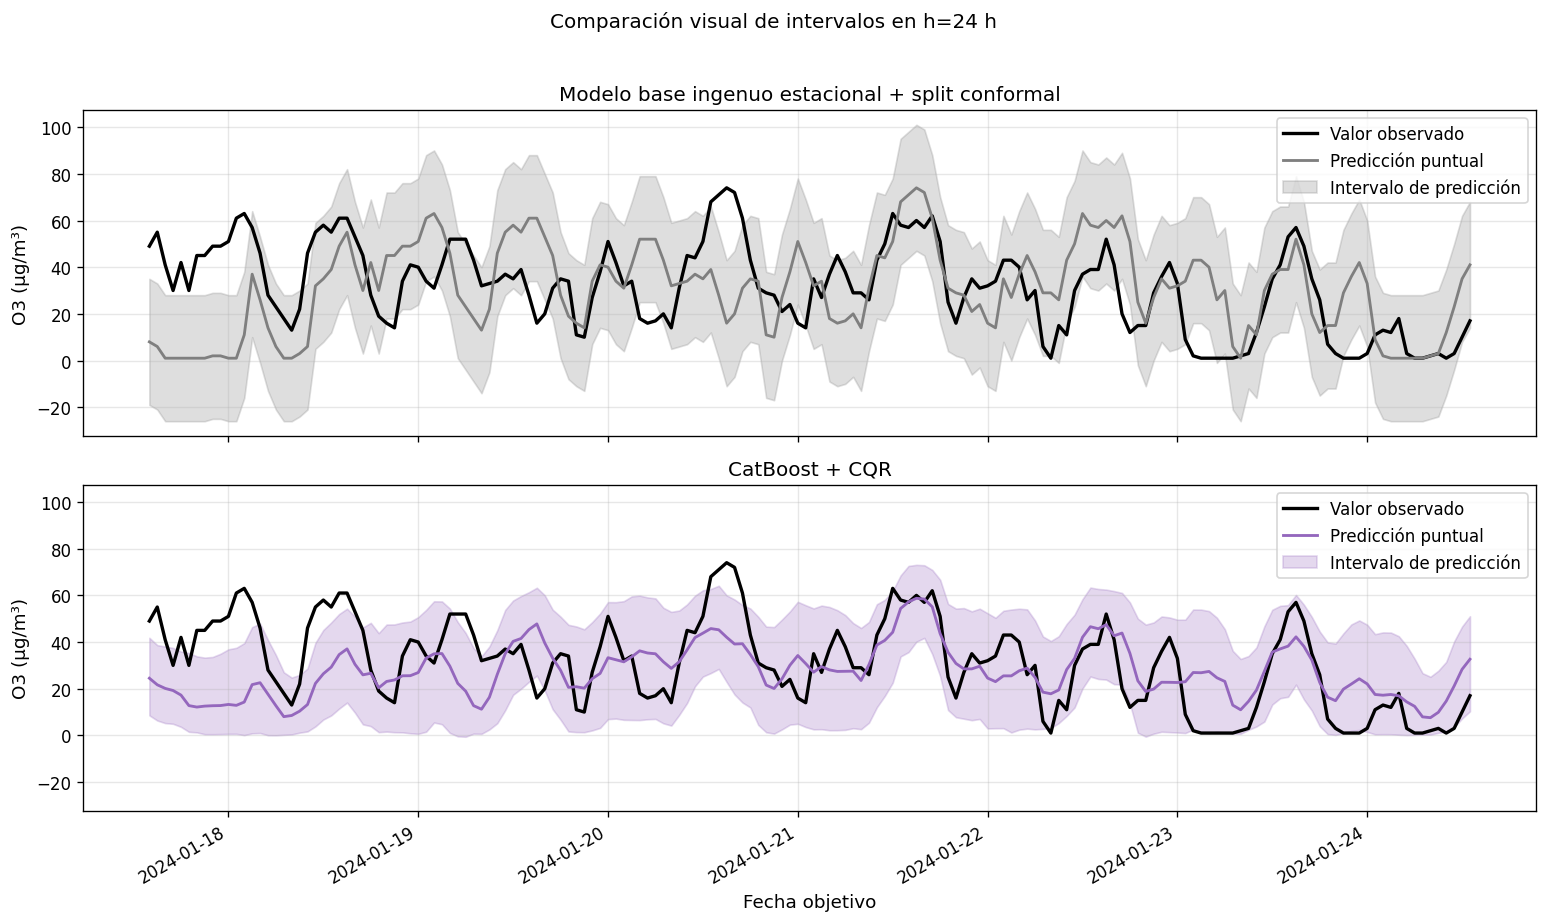

In [26]:
# Figura 4: comparación visual del modelo base y el mejor método supervisado para h=24
# ==============================================================================
example_best_row = (
    common_metrics_df.loc[
        (common_metrics_df["horizon"] == EXAMPLE_HORIZON)
        & (common_metrics_df["model"] != "baseline_seasonal_naive")
    ]
    .sort_values(
        ["mean_interval_score", "coverage_abs_error", "mean_width"],
        ascending=[True, True, True],
    )
    .iloc[0]
)

best_supervised_model = example_best_row["model"]
print(
    f"Mejor método supervisado en h={EXAMPLE_HORIZON} h: "
    f"{MODEL_REGISTRY[best_supervised_model]['label']}"
)

baseline_example = common_intervals.loc[
    (common_intervals["model"] == "baseline_seasonal_naive")
    & (common_intervals["horizon"] == EXAMPLE_HORIZON)
].copy()

best_example = common_intervals.loc[
    (common_intervals["model"] == best_supervised_model)
    & (common_intervals["horizon"] == EXAMPLE_HORIZON)
].copy()

# Se restringe a los instantes comunes entre ambos para evitar huecos distintos.
shared_targets = sorted(
    set(baseline_example["target_timestamp"]).intersection(
        set(best_example["target_timestamp"])
    )
)

baseline_example = baseline_example.loc[
    baseline_example["target_timestamp"].isin(shared_targets)
].copy()

best_example = best_example.loc[
    best_example["target_timestamp"].isin(shared_targets)
].copy()

# Se selecciona un bloque continuo de fechas para mostrar el ejemplo visual.
baseline_block = select_continuous_block(baseline_example, n_hours=EXAMPLE_HOURS)
block_targets = set(baseline_block["target_timestamp"])

best_block = (
    best_example.loc[best_example["target_timestamp"].isin(block_targets)]
    .copy()
    .sort_values("target_timestamp")
)

# Se guarda también una tabla con los valores mostrados en la figura.
example_block_path = (
    REPORTS_TABLES_DIR / f"interval_example_best_vs_baseline_h{EXAMPLE_HORIZON:02d}.csv"
)

comparison_block_df = baseline_block[
    ["target_timestamp", "y_true", "y_pred_reference", "lower", "upper"]
].copy()

comparison_block_df = comparison_block_df.rename(
    columns={
        "y_pred_reference": "baseline_y_pred",
        "lower": "baseline_lower",
        "upper": "baseline_upper",
    }
).merge(
    best_block[
        ["target_timestamp", "y_pred_reference", "lower", "upper"]
    ].rename(
        columns={
            "y_pred_reference": "best_y_pred",
            "lower": "best_lower",
            "upper": "best_upper",
        }
    ),
    on="target_timestamp",
    how="left",
)

comparison_block_df.to_csv(example_block_path, index=False)
print(f"Tabla de ejemplo guardada: {example_block_path}")

# Se utiliza un rango común para ambas gráficas
y_values = pd.concat(
    [
        baseline_block["y_true"],
        baseline_block["y_pred_reference"],
        baseline_block["lower"],
        baseline_block["upper"],
        best_block["y_true"],
        best_block["y_pred_reference"],
        best_block["lower"],
        best_block["upper"],
    ],
    axis=0,
).dropna()

y_min = y_values.min()
y_max = y_values.max()

# Se añade un pequeño margen vertical para que la figura respire mejor.
y_margin = 0.05 * (y_max - y_min)
if y_margin == 0:
    y_margin = 1.0

common_ylim = (y_min - y_margin, y_max + y_margin)

# Se pinta la figura
fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)

# Panel superior: el modelo base
axes[0].plot(
    baseline_block["target_timestamp"],
    baseline_block["y_true"],
    label="Valor observado",
    linewidth=2,
    color="black",
)

axes[0].plot(
    baseline_block["target_timestamp"],
    baseline_block["y_pred_reference"],
    label="Predicción puntual",
    linewidth=1.7,
    color=MODEL_REGISTRY["baseline_seasonal_naive"]["color"],
)

axes[0].fill_between(
    baseline_block["target_timestamp"],
    baseline_block["lower"],
    baseline_block["upper"],
    alpha=0.25,
    color=MODEL_REGISTRY["baseline_seasonal_naive"]["color"],
    label="Intervalo de predicción",
)

axes[0].set_title("Modelo base ingenuo estacional + split conformal")
axes[0].set_ylabel("O3 (µg/m³)")
axes[0].set_ylim(common_ylim)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right")

# Panel de abajo: el mejor método supervisado.
axes[1].plot(
    best_block["target_timestamp"],
    best_block["y_true"],
    label="Valor observado",
    linewidth=2,
    color="black",
)

axes[1].plot(
    best_block["target_timestamp"],
    best_block["y_pred_reference"],
    label="Predicción puntual",
    linewidth=1.7,
    color=MODEL_REGISTRY[best_supervised_model]["color"],
)

axes[1].fill_between(
    best_block["target_timestamp"],
    best_block["lower"],
    best_block["upper"],
    alpha=0.25,
    color=MODEL_REGISTRY[best_supervised_model]["color"],
    label="Intervalo de predicción",
)

axes[1].set_title(MODEL_REGISTRY[best_supervised_model]["label"])
axes[1].set_ylabel("O3 (µg/m³)")
axes[1].set_xlabel("Fecha objetivo")
axes[1].set_ylim(common_ylim)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

fig.suptitle(f"Comparación visual de intervalos en h={EXAMPLE_HORIZON} h", y=1.02)
fig.autofmt_xdate()
fig.tight_layout()

zoom_path = REPORTS_FIGURES_DIR / f"fig_interval_zoom_best_vs_baseline_h{EXAMPLE_HORIZON:02d}.png"
fig.savefig(zoom_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {zoom_path}")
plt.show()

In [27]:
# ==============================================================================
# Selección reproducible de un tramo para visualizar CatBoost cuantílico y CQR
# ==============================================================================

import matplotlib.dates as mdates
from matplotlib.patches import Patch
import sys

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

from visual_window_selection import (
    find_candidate_continuous_windows,
    load_visual_master_window,
    match_window_by_start_end,
)

CATBOOST_MODEL_ID = "catboost"
CATBOOST_VISUAL_HORIZONS = [1, 4, 24]

# Horizontes usados para evaluar la selección del tramo visual.
# Pueden incluir horizontes que no se representen finalmente en la figura.
CATBOOST_WINDOW_SELECTION_HORIZONS = [1, 4, 12, 24]

CATBOOST_DATA_HORIZONS = sorted(
    set(CATBOOST_VISUAL_HORIZONS)
    | set(CATBOOST_WINDOW_SELECTION_HORIZONS)
)

CATBOOST_VISUAL_HOURS = 7 * 24  # 7 días

# Se priorizan episodios con concentración elevada de O3.
# 0.75 = tramos cuyo p90 observado está en el 25 % superior.
USE_HIGH_O3_FILTER = True
HIGH_O3_QUANTILE = 0.75

# Se escoge un tramo de dificultad intermedia según interval score calibrado.
# 0.50 = mediana. Si quieres un tramo algo más favorable, pero no extremo, usa 0.40.
TARGET_INTERVAL_SCORE_QUANTILE = 0.50

# Para que las fechas sean legibles, se prefieren tramos que empiecen a las 00:00.
PREFER_DAILY_STARTS = True

# Para mantener coherencia con las figuras puntuales, se usa el tramo maestro
# seleccionado y guardado previamente por el notebook 05.
USE_MASTER_VISUAL_WINDOW = True
VISUAL_MASTER_WINDOW_PATH = REPORTS_TABLES_DIR / "visual_master_selected_window.csv"

# Se usa common_intervals para mantener la lógica de comparación sobre instantes comunes.
SOURCE_INTERVALS = common_intervals.copy()
SOURCE_INTERVALS["target_timestamp"] = pd.to_datetime(SOURCE_INTERVALS["target_timestamp"])


def first_existing_column(df: pd.DataFrame, candidates: list[str], purpose: str) -> str:
    """Devuelve la primera columna existente dentro de una lista de candidatas."""
    for col in candidates:
        if col in df.columns:
            return col

    raise KeyError(
        f"No se encontró ninguna columna para {purpose}.\n"
        f"Candidatas probadas: {candidates}\n"
        f"Columnas disponibles: {list(df.columns)}"
    )


# La función find_candidate_continuous_windows se importa desde scripts/visual_window_selection.py.

# ------------------------------------------------------------------------------
# 1. DataFrames de CatBoost por horizonte
# ------------------------------------------------------------------------------

catboost_intervals_by_horizon = {}

for horizon in CATBOOST_DATA_HORIZONS:
    df_h = SOURCE_INTERVALS.loc[
        (SOURCE_INTERVALS["model"] == CATBOOST_MODEL_ID)
        & (SOURCE_INTERVALS["horizon"] == horizon)
    ].copy()

    if df_h.empty:
        raise ValueError(f"No hay datos de CatBoost para h={horizon}.")

    df_h = df_h.sort_values("target_timestamp").reset_index(drop=True)

    central_col = first_existing_column(
        df_h,
        [
            "y_pred_quantile_median",
            "y_pred_reference",
            "y_pred_point",
            "y_pred",
            "y_pred_mapie",
            "median",
            "pred_median",
        ],
        purpose=f"predicción central / mediana en h={horizon}",
    )

    prelim_lower_col = first_existing_column(
        df_h,
        [
            "lower_prelim",
            "y_pred_quantile_lower",
            "y_pred_lower",
            "quantile_lower",
            "lower_quantile",
            "q_lower",
        ],
        purpose=f"cuantil inferior preliminar en h={horizon}",
    )

    prelim_upper_col = first_existing_column(
        df_h,
        [
            "upper_prelim",
            "y_pred_quantile_upper",
            "y_pred_upper",
            "quantile_upper",
            "upper_quantile",
            "q_upper",
        ],
        purpose=f"cuantil superior preliminar en h={horizon}",
    )

    required_cols = ["target_timestamp", "y_true", "lower", "upper", "interval_score"]
    missing_cols = [col for col in required_cols if col not in df_h.columns]

    if missing_cols:
        raise KeyError(
            f"Faltan columnas necesarias para CatBoost h={horizon}: {missing_cols}"
        )

    # Columnas normalizadas para que las figuras sean independientes de los nombres originales.
    df_h["central_pred"] = df_h[central_col]
    df_h["prelim_lower"] = df_h[prelim_lower_col]
    df_h["prelim_upper"] = df_h[prelim_upper_col]
    df_h["calibrated_lower"] = df_h["lower"]
    df_h["calibrated_upper"] = df_h["upper"]

    catboost_intervals_by_horizon[horizon] = df_h

    print(
        f"h={horizon}: columna central = {central_col}, "
        f"cuantil inferior = {prelim_lower_col}, "
        f"cuantil superior = {prelim_upper_col}"
    )


# ------------------------------------------------------------------------------
# 2. Timestamps comunes a h=1, h=4 y h=24
# ------------------------------------------------------------------------------

common_targets_across_horizons = set.intersection(
    *[
        set(pd.DatetimeIndex(catboost_intervals_by_horizon[horizon]["target_timestamp"]))
        for horizon in CATBOOST_WINDOW_SELECTION_HORIZONS
    ]
)

common_targets_df = (
    pd.DataFrame({"target_timestamp": sorted(common_targets_across_horizons)})
    .sort_values("target_timestamp")
    .reset_index(drop=True)
)

if common_targets_df.empty:
    raise ValueError("No hay timestamps comunes para los horizontes seleccionados.")

candidate_windows = find_candidate_continuous_windows(
    timestamps=common_targets_df["target_timestamp"],
    n_hours=CATBOOST_VISUAL_HOURS,
    prefer_daily_starts=PREFER_DAILY_STARTS,
)

if not candidate_windows:
    raise ValueError(
        f"No se encontraron tramos continuos de {CATBOOST_VISUAL_HOURS} horas "
        f"comunes a los horizontes {CATBOOST_WINDOW_SELECTION_HORIZONS}."
    )

print(f"Tramos candidatos encontrados: {len(candidate_windows)}")


# ------------------------------------------------------------------------------
# 3. Evaluación de tramos candidatos
# ------------------------------------------------------------------------------

candidate_rows = []

for window_idx, candidate_window in enumerate(candidate_windows):
    candidate_targets = set(candidate_window["target_timestamps"])

    observed_values = None

    calibrated_scores = []
    calibrated_widths = []
    calibrated_coverages = []

    prelim_scores = []
    prelim_widths = []
    prelim_coverages = []

    central_abs_errors = []

    valid_window = True

    for horizon in CATBOOST_WINDOW_SELECTION_HORIZONS:
        df_h = catboost_intervals_by_horizon[horizon]

        block_h = df_h.loc[
            df_h["target_timestamp"].isin(candidate_targets)
        ].copy()

        block_h = block_h.sort_values("target_timestamp").reset_index(drop=True)

        if len(block_h) != CATBOOST_VISUAL_HOURS:
            valid_window = False
            break

        if observed_values is None:
            observed_values = block_h["y_true"].to_numpy()

        # Intervalos calibrados mediante CQR
        calibrated_scores.append(block_h["interval_score"].to_numpy())
        calibrated_widths.append(
            (block_h["calibrated_upper"] - block_h["calibrated_lower"]).to_numpy()
        )
        calibrated_coverages.append(
            (
                (block_h["y_true"] >= block_h["calibrated_lower"])
                & (block_h["y_true"] <= block_h["calibrated_upper"])
            ).to_numpy()
        )

        # Intervalos cuantílicos preliminares
        prelim_score_h = interval_score(
            block_h["y_true"],
            block_h["prelim_lower"],
            block_h["prelim_upper"],
            ALPHA,
        )

        prelim_scores.append(prelim_score_h)
        prelim_widths.append(
            (block_h["prelim_upper"] - block_h["prelim_lower"]).to_numpy()
        )
        prelim_coverages.append(
            (
                (block_h["y_true"] >= block_h["prelim_lower"])
                & (block_h["y_true"] <= block_h["prelim_upper"])
            ).to_numpy()
        )

        # Error absoluto de la predicción central
        central_abs_errors.append(
            np.abs(block_h["y_true"].to_numpy() - block_h["central_pred"].to_numpy())
        )

    if not valid_window or observed_values is None:
        continue

    calibrated_scores = np.concatenate(calibrated_scores)
    calibrated_widths = np.concatenate(calibrated_widths)
    calibrated_coverages = np.concatenate(calibrated_coverages)

    prelim_scores = np.concatenate(prelim_scores)
    prelim_widths = np.concatenate(prelim_widths)
    prelim_coverages = np.concatenate(prelim_coverages)

    central_abs_errors = np.concatenate(central_abs_errors)

    candidate_rows.append(
        {
            "window_idx": window_idx,
            "start": candidate_window["start"],
            "end": candidate_window["end"],
            "n_hours": CATBOOST_VISUAL_HOURS,

            "observed_mean": float(np.mean(observed_values)),
            "observed_p90": float(np.quantile(observed_values, 0.90)),
            "observed_max": float(np.max(observed_values)),

            "central_mae": float(np.mean(central_abs_errors)),

            "prelim_coverage": float(np.mean(prelim_coverages)),
            "prelim_mean_width": float(np.mean(prelim_widths)),
            "prelim_mean_interval_score": float(np.mean(prelim_scores)),

            "calibrated_coverage": float(np.mean(calibrated_coverages)),
            "calibrated_mean_width": float(np.mean(calibrated_widths)),
            "calibrated_mean_interval_score": float(np.mean(calibrated_scores)),
        }
    )

candidate_windows_df = pd.DataFrame(candidate_rows)

if candidate_windows_df.empty:
    raise ValueError("No se pudo evaluar ningún tramo candidato válido.")

candidate_table_path = REPORTS_TABLES_DIR / "catboost_cqr_visual_candidate_windows.csv"
candidate_windows_df.to_csv(candidate_table_path, index=False)
print(f"Tabla de tramos candidatos guardada en: {candidate_table_path}")


# ------------------------------------------------------------------------------
# 4. Selección reproducible del tramo
# ------------------------------------------------------------------------------

if USE_HIGH_O3_FILTER:
    high_o3_threshold = candidate_windows_df["observed_p90"].quantile(
        HIGH_O3_QUANTILE
    )

    candidate_windows_df["passes_high_o3_filter"] = (
        candidate_windows_df["observed_p90"] >= high_o3_threshold
    )

    selectable_windows_df = candidate_windows_df.loc[
        candidate_windows_df["passes_high_o3_filter"]
    ].copy()

    print(
        "Filtro de alta concentración activado:",
        f"p90 observado >= {high_o3_threshold:.2f} µg/m³",
        f"({len(selectable_windows_df)} tramos elegibles)",
    )
else:
    high_o3_threshold = np.nan
    candidate_windows_df["passes_high_o3_filter"] = True
    selectable_windows_df = candidate_windows_df.copy()

    print(
        "Filtro de alta concentración desactivado:",
        f"{len(selectable_windows_df)} tramos elegibles",
    )

if selectable_windows_df.empty:
    raise ValueError("No quedan tramos elegibles tras aplicar el filtro de concentración.")

target_interval_score = selectable_windows_df["calibrated_mean_interval_score"].quantile(
    TARGET_INTERVAL_SCORE_QUANTILE
)

candidate_windows_df["distance_to_target_interval_score"] = (
    candidate_windows_df["calibrated_mean_interval_score"] - target_interval_score
).abs()

candidate_windows_df["coverage_abs_error"] = (
    candidate_windows_df["calibrated_coverage"] - NOMINAL_COVERAGE
).abs()

selectable_windows_df = candidate_windows_df.loc[
    candidate_windows_df["passes_high_o3_filter"]
].copy()

# Criterio final:
# 1) interval score medio calibrado cercano al cuantil objetivo;
# 2) cobertura del tramo más cercana a la nominal;
# 3) mayor p90 observado;
# 4) orden cronológico.
if USE_MASTER_VISUAL_WINDOW:
    master_window = load_visual_master_window(VISUAL_MASTER_WINDOW_PATH)

    matched_windows_df = match_window_by_start_end(
        candidate_windows_df=candidate_windows_df,
        start=master_window["start"],
        end=master_window["end"],
    )

    if matched_windows_df.empty:
        raise ValueError(
            "El tramo visual maestro seleccionado en el notebook 05 no está disponible "
            "como tramo continuo válido en el notebook 07.\n"
            f"Tramo maestro: {master_window['start']} → {master_window['end']}\n"
            "Revisa que la longitud del tramo y los timestamps comunes coincidan."
        )

    selected_window = matched_windows_df.iloc[0]

    print("\nTramo visual maestro cargado desde el notebook 05:")
    print(f"Inicio: {pd.Timestamp(master_window['start'])}")
    print(f"Fin: {pd.Timestamp(master_window['end'])}")
    print(
        "Supera el filtro de alta concentración del notebook 07:",
        bool(selected_window["passes_high_o3_filter"]),
    )
else:
    selected_window = (
        selectable_windows_df
        .sort_values(
            [
                "distance_to_target_interval_score",
                "coverage_abs_error",
                "observed_p90",
                "start",
            ],
            ascending=[True, True, False, True],
        )
        .iloc[0]
    )

CATBOOST_VISUAL_START_TS = pd.Timestamp(selected_window["start"])
CATBOOST_VISUAL_END_TS = pd.Timestamp(selected_window["end"])

selected_visual_targets = set(
    pd.date_range(
        start=CATBOOST_VISUAL_START_TS,
        end=CATBOOST_VISUAL_END_TS,
        freq="h",
    )
)

print("\nTramo seleccionado de forma reproducible:")
print(f"Inicio: {CATBOOST_VISUAL_START_TS}")
print(f"Fin: {CATBOOST_VISUAL_END_TS}")
print(f"Horas: {CATBOOST_VISUAL_HOURS}")
print(f"Media observada O3: {selected_window['observed_mean']:.2f} µg/m³")
print(f"p90 observado O3: {selected_window['observed_p90']:.2f} µg/m³")
print(f"Máximo observado O3: {selected_window['observed_max']:.2f} µg/m³")
print(f"MAE central medio: {selected_window['central_mae']:.2f}")
print(f"Cobertura preliminar del tramo: {selected_window['prelim_coverage']:.3f}")
print(f"Cobertura calibrada del tramo: {selected_window['calibrated_coverage']:.3f}")
print(f"Anchura media calibrada: {selected_window['calibrated_mean_width']:.2f}")
print(f"Interval score preliminar medio: {selected_window['prelim_mean_interval_score']:.2f}")
print(f"Interval score calibrado medio: {selected_window['calibrated_mean_interval_score']:.2f}")
print(f"Interval score objetivo: {target_interval_score:.2f}")

# Se actualiza la tabla de candidatos con las columnas usadas para selección.
candidate_windows_df.to_csv(candidate_table_path, index=False)
print(f"Tabla de tramos candidatos actualizada en: {candidate_table_path}")

# ------------------------------------------------------------------------------
# 5. Bloques finales por horizonte para las figuras
# ------------------------------------------------------------------------------

catboost_visual_blocks_by_horizon = {}

for horizon in CATBOOST_VISUAL_HORIZONS:
    df_h = catboost_intervals_by_horizon[horizon]

    block_h = df_h.loc[
        df_h["target_timestamp"].isin(selected_visual_targets)
    ].copy()

    block_h = block_h.sort_values("target_timestamp").reset_index(drop=True)

    if len(block_h) != CATBOOST_VISUAL_HOURS:
        raise ValueError(
            f"El bloque seleccionado para h={horizon} tiene {len(block_h)} filas, "
            f"pero se esperaban {CATBOOST_VISUAL_HOURS}."
        )

    catboost_visual_blocks_by_horizon[horizon] = block_h

    print(
        f"h={horizon}: "
        f"{block_h['target_timestamp'].min()} → {block_h['target_timestamp'].max()} "
        f"({len(block_h)} observaciones)"
    )

selected_window_path = REPORTS_TABLES_DIR / "catboost_cqr_visual_selected_window.csv"
pd.DataFrame([selected_window]).to_csv(selected_window_path, index=False)
print(f"Resumen del tramo seleccionado guardado en: {selected_window_path}")

h=1: columna central = y_pred_quantile_median, cuantil inferior = lower_prelim, cuantil superior = upper_prelim
h=4: columna central = y_pred_quantile_median, cuantil inferior = lower_prelim, cuantil superior = upper_prelim
h=12: columna central = y_pred_quantile_median, cuantil inferior = lower_prelim, cuantil superior = upper_prelim
h=24: columna central = y_pred_quantile_median, cuantil inferior = lower_prelim, cuantil superior = upper_prelim
Tramos candidatos encontrados: 129
Tabla de tramos candidatos guardada en: c:\trabajo_github\reports\tables\catboost_cqr_visual_candidate_windows.csv
Filtro de alta concentración activado: p90 observado >= 86.00 µg/m³ (34 tramos elegibles)

Tramo visual maestro cargado desde el notebook 05:
Inicio: 2024-06-25 00:00:00
Fin: 2024-07-01 23:00:00
Supera el filtro de alta concentración del notebook 07: True

Tramo seleccionado de forma reproducible:
Inicio: 2024-06-25 00:00:00
Fin: 2024-07-01 23:00:00
Horas: 168
Media observada O3: 58.93 µg/m³
p90 o

Fuente usada para el modelo base: common_intervals
Tramo visual: 2024-06-25 00:00:00 → 2024-07-01 23:00:00
Filas detectadas como modelo base: 33060
Valores detectados en 'model': ['baseline_seasonal_naive']
Valores detectados en 'label': ['Baseline + split conformal']
Valores detectados en 'method': ['split_conformal']

q_hat ≈ 27.000 µg/m³
Anchura ≈ 54.000 µg/m³
Tramo del modelo base: 2024-06-25 00:00:00 → 2024-07-01 23:00:00 (168 observaciones)
Tabla del tramo guardada en: c:\trabajo_github\reports\tables\split_conformal_baseline_selected_window_all_horizons.csv
Figura guardada en: c:\trabajo_github\reports\figures\fig_split_conformal_baseline_selected_window_all_horizons.png


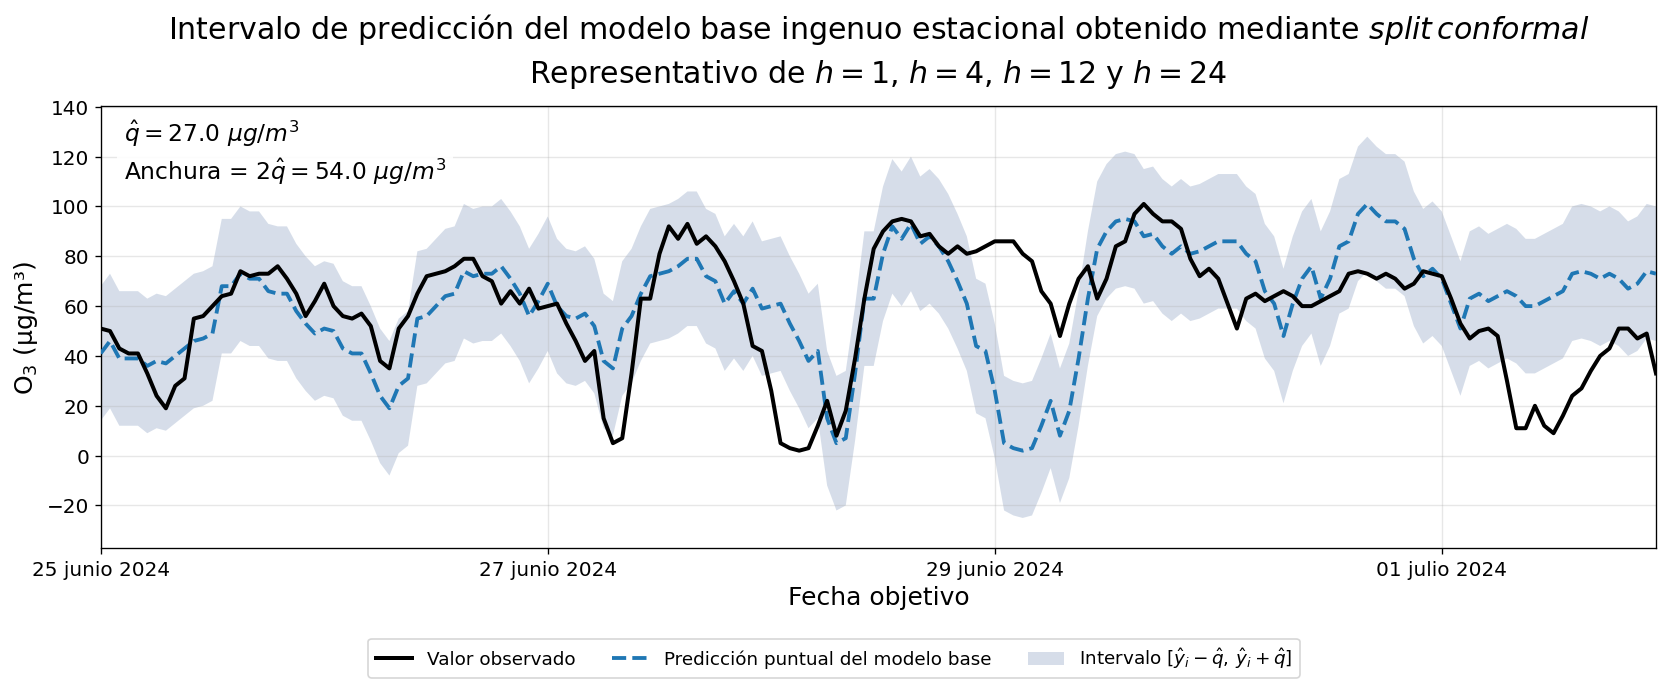

In [28]:
# ==============================================================================
# Figura: intervalo de predicción del modelo base con split conformal
# - usa el mismo tramo seleccionado para CatBoost/CQR
# - representativa de todos los horizontes
# - leyenda debajo
# - meses en letras y minúscula
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

# ------------------------------------------------------------------------------
# Configuración
# ------------------------------------------------------------------------------
# Aunque el intervalo del modelo base es idéntico para todos los horizontes,
# se toma uno de ellos para extraer las filas.
BASELINE_VISUAL_HORIZON = 24

# Si existe baseline_intervals en memoria, se usará directamente.
# En caso contrario, se intentará recuperar el modelo base desde common_intervals.
SOURCE_BASELINE_INTERVALS = common_intervals.copy()
SOURCE_NAME = "common_intervals"

SOURCE_BASELINE_INTERVALS["target_timestamp"] = pd.to_datetime(
    SOURCE_BASELINE_INTERVALS["target_timestamp"]
)

# Se reutiliza el tramo ya seleccionado en la celda de CatBoost/CQR
if "CATBOOST_VISUAL_START_TS" not in globals() or "CATBOOST_VISUAL_END_TS" not in globals():
    selected_window_path = REPORTS_TABLES_DIR / "catboost_cqr_visual_selected_window.csv"

    if selected_window_path.exists():
        selected_window_df = pd.read_csv(selected_window_path)
        VISUAL_START_TS = pd.Timestamp(selected_window_df.loc[0, "start"])
        VISUAL_END_TS = pd.Timestamp(selected_window_df.loc[0, "end"])
    else:
        raise ValueError(
            "No se encontraron CATBOOST_VISUAL_START_TS y CATBOOST_VISUAL_END_TS, "
            "ni el archivo catboost_cqr_visual_selected_window.csv. "
            "Ejecuta primero la celda de selección reproducible del tramo."
        )
else:
    VISUAL_START_TS = pd.Timestamp(CATBOOST_VISUAL_START_TS)
    VISUAL_END_TS = pd.Timestamp(CATBOOST_VISUAL_END_TS)

print(f"Fuente usada para el modelo base: {SOURCE_NAME}")
print(f"Tramo visual: {VISUAL_START_TS} → {VISUAL_END_TS}")

# ------------------------------------------------------------------------------
# Funciones auxiliares
# ------------------------------------------------------------------------------
def first_existing_column(df: pd.DataFrame, candidates: list[str], purpose: str) -> str:
    """Devuelve la primera columna existente dentro de una lista de candidatas."""
    for col in candidates:
        if col in df.columns:
            return col

    raise KeyError(
        f"No se encontró ninguna columna para {purpose}.\n"
        f"Candidatas probadas: {candidates}\n"
        f"Columnas disponibles: {list(df.columns)}"
    )


def detect_baseline_mask(df: pd.DataFrame) -> pd.Series:
    """
    Detecta filas del modelo base de forma flexible.

    Se buscan términos como baseline, base, naive, ingenuo, seasonal o split
    en columnas textuales como model, label, method o model_id, excluyendo
    explícitamente modelos supervisados.
    """
    preferred_text_cols = [
        "model",
        "label",
        "method",
        "model_id",
        "estimator",
    ]

    text_cols = [col for col in preferred_text_cols if col in df.columns]

    if not text_cols:
        # Si no hay columnas textuales de identificación, se asume que la fuente
        # ya corresponde al modelo base. Esto suele ocurrir si se usa baseline_intervals.
        print(
            "No se encontraron columnas textuales de identificación; "
            "se asume que todas las filas corresponden al modelo base."
        )
        return pd.Series(True, index=df.index)

    combined_text = (
        df[text_cols]
        .astype(str)
        .agg(" ".join, axis=1)
        .str.lower()
    )

    include_patterns = [
        "baseline",
        "modelo base",
        "base",
        "naive",
        "ingenuo",
        "seasonal",
        "split",
    ]

    exclude_patterns = [
        "catboost",
        "lightgbm",
        "lgbm",
        "linear",
        "lineal",
        "regresión lineal",
        "regresion lineal",
        "cqr",
    ]

    include_mask = combined_text.str.contains(
        "|".join(include_patterns),
        regex=True,
        na=False,
    )

    exclude_mask = combined_text.str.contains(
        "|".join(exclude_patterns),
        regex=True,
        na=False,
    )

    baseline_mask = include_mask & ~exclude_mask

    if not baseline_mask.any():
        available_info = {}

        for col in text_cols:
            available_info[col] = (
                df[col]
                .dropna()
                .astype(str)
                .drop_duplicates()
                .sort_values()
                .tolist()
            )

        raise KeyError(
            "No se pudo identificar el modelo base de forma automática.\n"
            f"Columnas revisadas: {text_cols}\n"
            f"Valores disponibles: {available_info}"
        )

    print(f"Filas detectadas como modelo base: {baseline_mask.sum()}")

    for col in text_cols:
        values = (
            df.loc[baseline_mask, col]
            .dropna()
            .astype(str)
            .drop_duplicates()
            .sort_values()
            .tolist()
        )

        if values:
            print(f"Valores detectados en '{col}': {values}")

    return baseline_mask


SPANISH_MONTH_ABBR = {
    1: "enero",
    2: "febrero",
    3: "marzo",
    4: "abril",
    5: "mayo",
    6: "junio",
    7: "julio",
    8: "agosto",
    9: "septiembre",
    10: "octubre",
    11: "noviembre",
    12: "diciembre",
}


def spanish_axis_date(x, pos=None):
    dt = mdates.num2date(x)
    return f"{dt.day:02d} {SPANISH_MONTH_ABBR[dt.month]} {dt.year}"


def format_spanish_date(ts):
    ts = pd.Timestamp(ts)
    return f"{ts.day:02d} {SPANISH_MONTH_ABBR[ts.month]} {ts.year}"


# ------------------------------------------------------------------------------
# 1. Localización del modelo base y selección del bloque
# ------------------------------------------------------------------------------
baseline_mask = detect_baseline_mask(SOURCE_BASELINE_INTERVALS)

if "horizon" not in SOURCE_BASELINE_INTERVALS.columns:
    raise KeyError("La fuente de intervalos no contiene la columna 'horizon'.")

# Conversión robusta del horizonte por si aparece como texto
SOURCE_BASELINE_INTERVALS["_horizon_num"] = pd.to_numeric(
    SOURCE_BASELINE_INTERVALS["horizon"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce",
)

df_base = SOURCE_BASELINE_INTERVALS.loc[
    baseline_mask
    & (SOURCE_BASELINE_INTERVALS["_horizon_num"] == BASELINE_VISUAL_HORIZON)
].copy()

if df_base.empty:
    available_horizons = (
        SOURCE_BASELINE_INTERVALS.loc[baseline_mask, "_horizon_num"]
        .dropna()
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    raise ValueError(
        f"No hay datos del modelo base para h={BASELINE_VISUAL_HORIZON}. "
        f"Horizontes disponibles para el modelo base: {available_horizons}"
    )

df_base = df_base.sort_values("target_timestamp").reset_index(drop=True)

pred_col = first_existing_column(
    df_base,
    [
        "y_pred",
        "y_pred_point",
        "y_pred_reference",
        "y_pred_baseline",
        "prediction",
        "pred",
        "y_hat",
    ],
    purpose="predicción puntual del modelo base",
)

required_cols = ["target_timestamp", "y_true", "lower", "upper"]
missing_cols = [col for col in required_cols if col not in df_base.columns]

if missing_cols:
    raise KeyError(
        f"Faltan columnas necesarias en el modelo base: {missing_cols}"
    )

example_block = df_base.loc[
    (df_base["target_timestamp"] >= VISUAL_START_TS)
    & (df_base["target_timestamp"] <= VISUAL_END_TS)
].copy()

example_block = example_block.sort_values("target_timestamp").reset_index(drop=True)

if example_block.empty:
    raise ValueError(
        "El tramo seleccionado no contiene observaciones del modelo base."
    )

expected_hours = int((VISUAL_END_TS - VISUAL_START_TS) / pd.Timedelta(hours=1)) + 1

if len(example_block) != expected_hours:
    print(
        f"Advertencia: el tramo contiene {len(example_block)} observaciones, "
        f"pero se esperaban {expected_hours}. Revisa si faltan timestamps."
    )

# ------------------------------------------------------------------------------
# 2. Columnas normalizadas y parámetros del intervalo
# ------------------------------------------------------------------------------
example_block["point_pred"] = example_block[pred_col]
example_block["interval_lower"] = example_block["lower"]
example_block["interval_upper"] = example_block["upper"]

# Cuantil conforme estimado a partir de la semianchura del intervalo
q_hat_series = 0.5 * (
    example_block["interval_upper"] - example_block["interval_lower"]
)

q_hat = float(np.nanmedian(q_hat_series))
interval_width = 2.0 * q_hat

print(f"\nq_hat ≈ {q_hat:.3f} µg/m³")
print(f"Anchura ≈ {interval_width:.3f} µg/m³")
print(
    "Tramo del modelo base:",
    example_block["target_timestamp"].min(),
    "→",
    example_block["target_timestamp"].max(),
    f"({len(example_block)} observaciones)",
)

# ------------------------------------------------------------------------------
# 3. Guardado del bloque visual
# ------------------------------------------------------------------------------
example_block_path = (
    REPORTS_TABLES_DIR
    / "split_conformal_baseline_selected_window_all_horizons.csv"
)

example_block.to_csv(example_block_path, index=False)
print(f"Tabla del tramo guardada en: {example_block_path}")

# ------------------------------------------------------------------------------
# 4. Estilo
# ------------------------------------------------------------------------------
observed_color = "black"
prediction_color = "#1f77b4"
interval_color = "#cfd8e6"

# ------------------------------------------------------------------------------
# 5. Figura
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6.8))

# Banda del intervalo
ax.fill_between(
    example_block["target_timestamp"],
    example_block["interval_lower"],
    example_block["interval_upper"],
    color=interval_color,
    alpha=0.85,
    edgecolor="none",
    linewidth=0,
    zorder=1,
)

# Valor observado
ax.plot(
    example_block["target_timestamp"],
    example_block["y_true"],
    color=observed_color,
    linewidth=2.4,
    label="Valor observado",
    zorder=4,
)

# Predicción puntual
ax.plot(
    example_block["target_timestamp"],
    example_block["point_pred"],
    color=prediction_color,
    linewidth=2.3,
    linestyle="--",
    label="Predicción puntual del modelo base",
    zorder=3,
)

# Texto informativo
ax.text(
    0.015,
    0.92,
    rf"$\hat{{q}} = {q_hat:.1f}\ \mu g/m^3$",
    transform=ax.transAxes,
    fontsize=14,
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.90,
        pad=4,
    ),
)

ax.text(
    0.015,
    0.835,
    rf"Anchura = $2\hat{{q}} = {interval_width:.1f}\ \mu g/m^3$",
    transform=ax.transAxes,
    fontsize=14,
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.90,
        pad=4,
    ),
)

# ------------------------------------------------------------------------------
# 6. Formato general
# ------------------------------------------------------------------------------
ax.set_title(
    r"Intervalo de predicción del modelo base ingenuo estacional obtenido mediante $split\, conformal$"
    "\n"
    r"Representativo de $h=1$, $h=4$, $h=12$ y $h=24$",
    fontsize=18,
    linespacing=1.45,
    pad=14,
)

ax.set_ylabel(r"$\mathrm{O}_3$ (µg/m³)", fontsize=15)
ax.set_xlabel("Fecha objetivo", fontsize=15)
ax.grid(True, alpha=0.3)
ax.tick_params(axis="both", labelsize=12)
ax.margins(x=0.01, y=0.08)
ax.set_xlim(VISUAL_START_TS, VISUAL_END_TS)

# ------------------------------------------------------------------------------
# 7. Fechas
# ------------------------------------------------------------------------------
tick_dates = pd.date_range(
    start=VISUAL_START_TS.normalize(),
    end=VISUAL_END_TS.normalize(),
    freq="2D",
)

ax.set_xticks(tick_dates)
ax.xaxis.set_major_formatter(FuncFormatter(spanish_axis_date))
ax.tick_params(axis="x", rotation=0)
plt.setp(ax.get_xticklabels(), ha="center")

# ------------------------------------------------------------------------------
# 8. Leyenda debajo
# ------------------------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color=observed_color,
        linewidth=2.4,
        label="Valor observado",
    ),
    Line2D(
        [0], [0],
        color=prediction_color,
        linewidth=2.3,
        linestyle="--",
        label="Predicción puntual del modelo base",
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.85,
        label=r"Intervalo $[\hat{y}_i-\hat{q},\,\hat{y}_i+\hat{q}]$",
    ),
]

legend = fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.03),
    ncol=3,
    fontsize=11,
    frameon=True,
)

# ------------------------------------------------------------------------------
# 10. Guardado
# ------------------------------------------------------------------------------
fig.tight_layout(rect=(0, 0.10, 1, 0.88))
fig.subplots_adjust(bottom=0.20)

interval_zoom_path = (
    REPORTS_FIGURES_DIR
    / "fig_split_conformal_baseline_selected_window_all_horizons.png"
)

fig.savefig(
    interval_zoom_path,
    dpi=300,
    bbox_inches="tight",
    bbox_extra_artists=(legend,),
)

print(f"Figura guardada en: {interval_zoom_path}")

plt.show()

Figura guardada en: c:\trabajo_github\reports\figures\fig_catboost_quantiles_prelim_h01_h04_h24.png


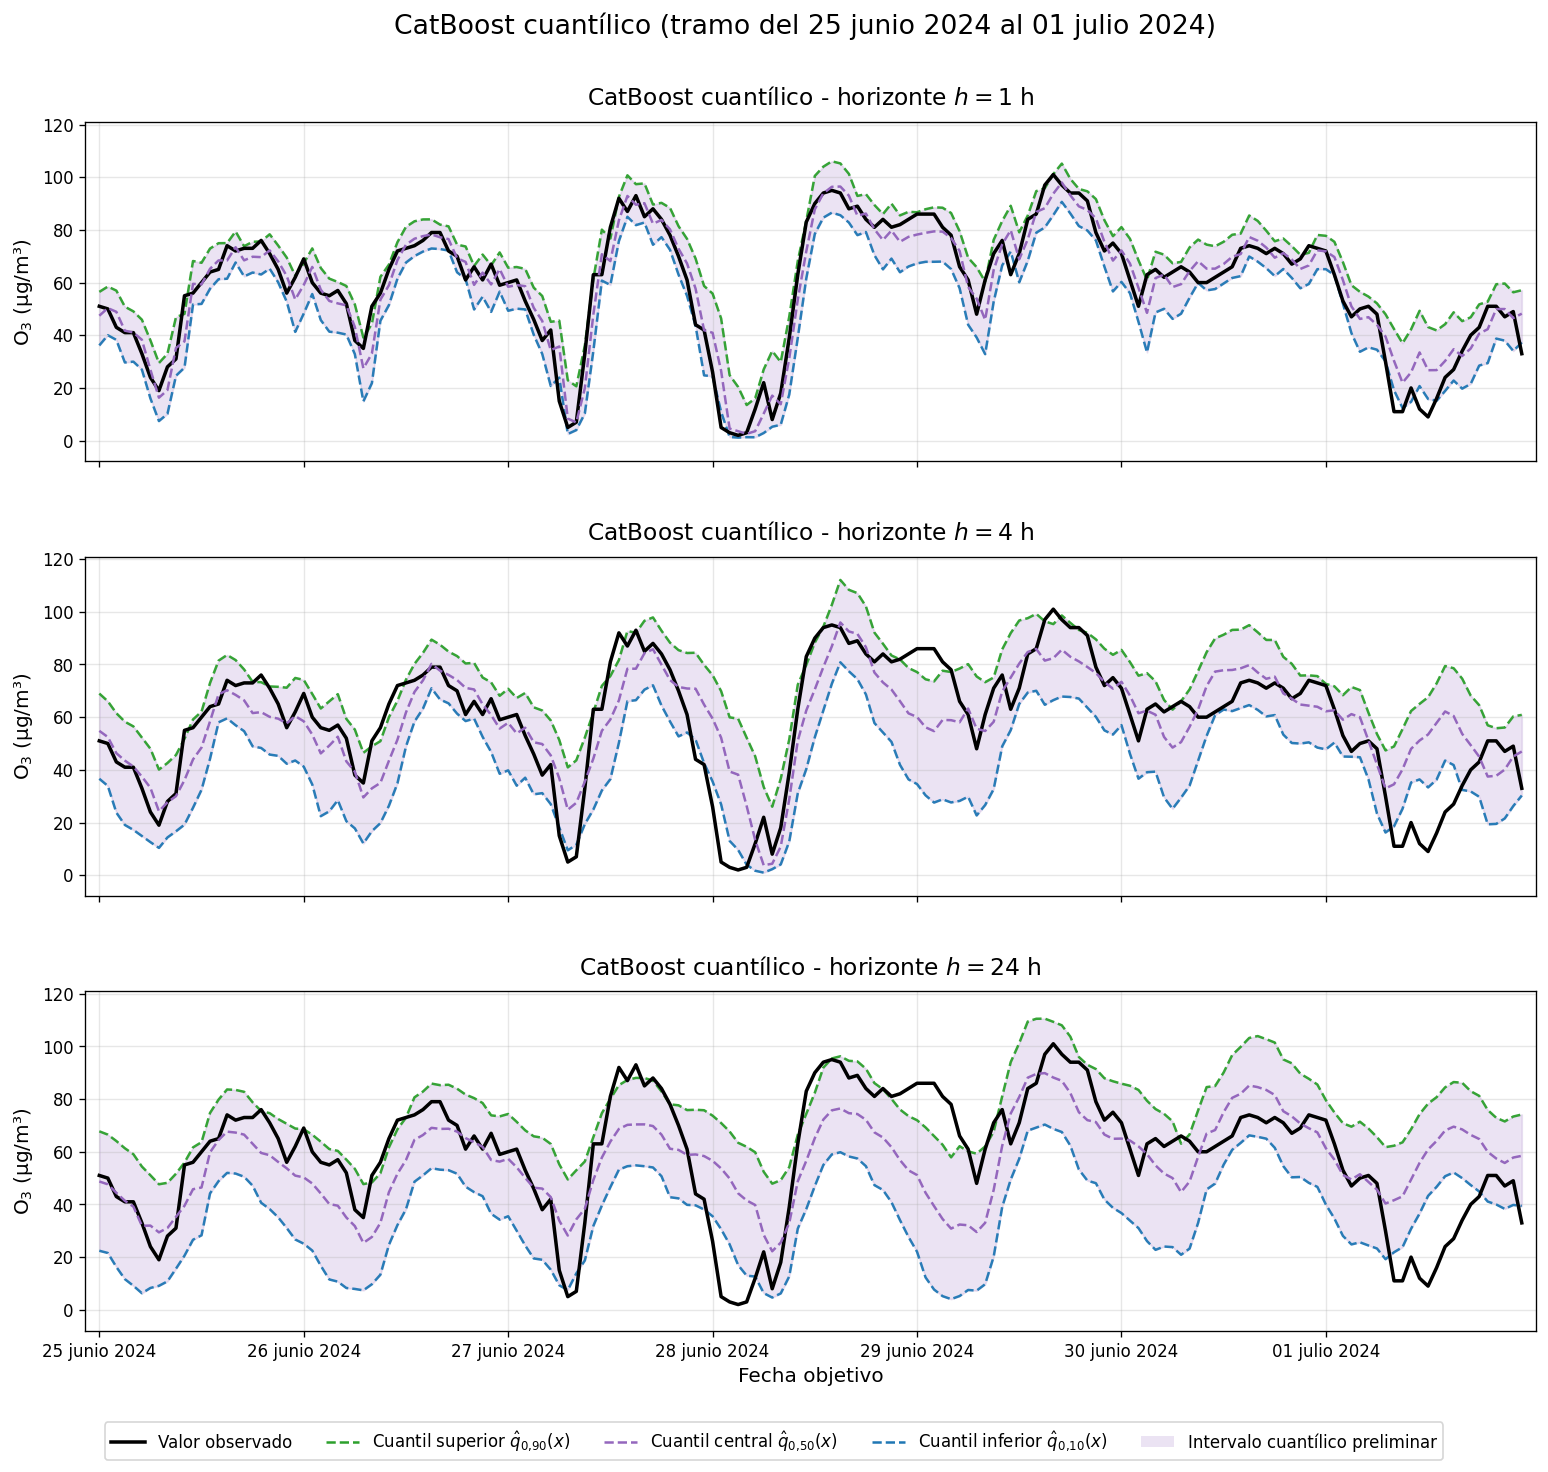

In [29]:
# ==============================================================================
# Figura: cuantiles preliminares de CatBoost con formato vertical
# - colores distintos por cuantil
# - mayor tamaño vertical por panel
# - fechas con el mes en letras
# ==============================================================================

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Configuración
# ------------------------------------------------------------------
CATBOOST_VISUAL_HORIZONS = [1, 4, 24]

def format_quantile_label(q: float) -> str:
    return f"{q:.2f}".replace(".", "{,}")

lower_quantile_label = format_quantile_label(ALPHA / 2)
upper_quantile_label = format_quantile_label(1 - ALPHA / 2)

observed_color = "black"
central_color = MODEL_REGISTRY[CATBOOST_MODEL_ID]["color"]   # color CatBoost
lower_color = "#1f77b4"   # azul
upper_color = "#2ca02c"   # verde
band_color = "#9467bd"    # morado suave para la banda

# ------------------------------------------------------------------
# Funciones auxiliares para fechas en español
# ------------------------------------------------------------------
SPANISH_MONTH_ABBR = {
    1: "enero",
    2: "Febrero",
    3: "marzo",
    4: "abril",
    5: "mayo",
    6: "junio",
    7: "julio",
    8: "agosto",
    9: "septiembre",
    10: "octubre",
    11: "noviembre",
    12: "diciembre",
}

def spanish_axis_date(x, pos=None):
    dt = mdates.num2date(x)
    return f"{dt.day:02d} {SPANISH_MONTH_ABBR[dt.month]} {dt.year}"

def format_spanish_date(ts):
    ts = pd.Timestamp(ts)
    return f"{ts.day:02d} {SPANISH_MONTH_ABBR[ts.month]} {ts.year}"

# ------------------------------------------------------------------
# Rango vertical común para todos los paneles
# ------------------------------------------------------------------
y_values = pd.concat(
    [
        block[["y_true", "central_pred", "prelim_lower", "prelim_upper"]].stack()
        for horizon, block in catboost_visual_blocks_by_horizon.items()
        if horizon in CATBOOST_VISUAL_HORIZONS
    ],
    axis=0,
).dropna()

y_min = y_values.min()
y_max = y_values.max()

y_margin = 0.08 * (y_max - y_min)
if y_margin == 0:
    y_margin = 1.0

common_ylim = (y_min - y_margin, y_max + y_margin)

# ------------------------------------------------------------------
# Figura
# ------------------------------------------------------------------
panel_height = 4.25
fig, axes = plt.subplots(
    len(CATBOOST_VISUAL_HORIZONS),
    1,
    figsize=(13, panel_height * len(CATBOOST_VISUAL_HORIZONS)),
    sharex=True,
    sharey=True,
)

if len(CATBOOST_VISUAL_HORIZONS) == 1:
    axes = [axes]

for ax, horizon in zip(axes, CATBOOST_VISUAL_HORIZONS):
    block = catboost_visual_blocks_by_horizon[horizon]

    # Banda del intervalo cuantílico preliminar
    ax.fill_between(
        block["target_timestamp"],
        block["prelim_lower"],
        block["prelim_upper"],
        color=band_color,
        alpha=0.18,
        zorder=1,
    )

    # Valor observado
    ax.plot(
        block["target_timestamp"],
        block["y_true"],
        color=observed_color,
        linewidth=2.1,
        label="Valor observado",
        zorder=4,
    )

    # Cuantil inferior
    ax.plot(
        block["target_timestamp"],
        block["prelim_lower"],
        color=lower_color,
        linewidth=1.5,
        linestyle="--",
        alpha=0.95,
        label=rf"Cuantil inferior $\hat{{q}}_{{{lower_quantile_label}}}(x)$",
        zorder=3,
    )

    # Cuantil central
    ax.plot(
        block["target_timestamp"],
        block["central_pred"],
        color=central_color,
        linewidth=1.5,
        linestyle="--",
        label=r"Cuantil central $\hat{q}_{0{,}50}(x)$",
        zorder=5,
    )

    # Cuantil superior
    ax.plot(
        block["target_timestamp"],
        block["prelim_upper"],
        color=upper_color,
        linewidth=1.5,
        linestyle="--",
        alpha=0.95,
        label=rf"Cuantil superior $\hat{{q}}_{{{upper_quantile_label}}}(x)$",
        zorder=3,
    )

    ax.set_title(
        rf"CatBoost cuantílico - horizonte $h={horizon}$ h",
        fontsize=14,
        pad=10,
    )

    ax.set_ylabel(r"$\mathrm{O}_3$ (µg/m³)", fontsize=12)
    ax.set_ylim(common_ylim)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=10)
    ax.margins(x=0.01, y=0.06)

axes[-1].set_xlabel("Fecha objetivo", fontsize=12)

# ------------------------------------------------------------------
# Formato de fechas: marcas cada 2 días y mes en letras
# ------------------------------------------------------------------
TICK_EVERY_N_DAYS = 1

axis_start = min(
    pd.to_datetime(catboost_visual_blocks_by_horizon[h]["target_timestamp"]).min()
    for h in CATBOOST_VISUAL_HORIZONS
).normalize()

axis_end = max(
    pd.to_datetime(catboost_visual_blocks_by_horizon[h]["target_timestamp"]).max()
    for h in CATBOOST_VISUAL_HORIZONS
).normalize()

tick_dates = pd.date_range(
    start=axis_start,
    end=axis_end,
    freq=f"{TICK_EVERY_N_DAYS}D",
)

date_formatter = FuncFormatter(spanish_axis_date)

for ax in axes:
    ax.set_xticks(tick_dates)
    ax.xaxis.set_major_formatter(date_formatter)
    ax.tick_params(axis="x", rotation=0)
    plt.setp(ax.get_xticklabels(), ha="center")

# ------------------------------------------------------------------
# Leyenda
# ------------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color=observed_color,
        linewidth=2.1,
        label="Valor observado",
    ),
    Line2D(
        [0], [0],
        color=upper_color,
        linewidth=1.5,
        linestyle="--",
        label=rf"Cuantil superior $\hat{{q}}_{{{upper_quantile_label}}}(x)$",
    ),
    Line2D(
        [0], [0],
        color=central_color,
        linewidth=1.5,
        linestyle="--",
        label=r"Cuantil central $\hat{q}_{0{,}50}(x)$",
    ),
    Line2D(
        [0], [0],
        color=lower_color,
        linewidth=1.5,
        linestyle="--",
        label=rf"Cuantil inferior $\hat{{q}}_{{{lower_quantile_label}}}(x)$",
    ),
    Patch(
        facecolor=band_color,
        alpha=0.18,
        label="Intervalo cuantílico preliminar",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=5,
    fontsize=10,
    frameon=True,
)

# ------------------------------------------------------------------
# Título general
# ------------------------------------------------------------------
fig.suptitle(
    "CatBoost cuantílico "
    f"(tramo del {format_spanish_date(CATBOOST_VISUAL_START_TS)} "
    f"al {format_spanish_date(CATBOOST_VISUAL_END_TS)})",
    fontsize=16,
    y=0.972,
    x=0.52,
    ha="center",
)

fig.tight_layout(rect=(0, 0.06, 1, 0.95))
fig.subplots_adjust(hspace=0.28, top=0.90, bottom=0.11)

quantiles_fig_path = (
    REPORTS_FIGURES_DIR / "fig_catboost_quantiles_prelim_h01_h04_h24.png"
)

fig.savefig(quantiles_fig_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {quantiles_fig_path}")

plt.show()


## Conclusión preliminar

La siguiente tabla hace un resumen de la selección preliminar por horizonte de acuerdo con el interval score calculado sobre los instantes objetivo comunes.


In [30]:

# Resumen de la selección preliminar

selection_summary_df = best_method_by_horizon_df[
    [
        "horizon",
        "label",
        "n_samples",
        "empirical_coverage",
        "mean_width",
        "mean_interval_score",
        "coverage_error",
    ]
].copy()
selection_summary_df = selection_summary_df.rename(
    columns={
        "label": "selected_method",
        "n_samples": "n_common_samples",
    }
)

# Se añade también el mejor método global según la media del interval score.
overall_ranking_df = (
    common_metrics_df.groupby(["model", "label"], as_index=False)
    .agg(
        mean_interval_score_across_horizons=("mean_interval_score", "mean"),
        mean_width_across_horizons=("mean_width", "mean"),
        mean_coverage_across_horizons=("empirical_coverage", "mean"),
    )
    .sort_values(["mean_interval_score_across_horizons", "mean_width_across_horizons"], ascending=[True, True])
    .reset_index(drop=True)
)
overall_ranking_df["global_rank"] = np.arange(1, len(overall_ranking_df) + 1)

selection_summary_path = REPORTS_TABLES_DIR / "interval_selection_summary.csv"
overall_ranking_path = REPORTS_TABLES_DIR / "interval_overall_ranking.csv"
selection_summary_df.to_csv(selection_summary_path, index=False)
overall_ranking_df.to_csv(overall_ranking_path, index=False)

print("Selección preliminar por horizonte:")
display(selection_summary_df)

print("Ranking global por media del interval score:")
display(overall_ranking_df)

print(f"Tabla guardada: {selection_summary_path}")
print(f"Tabla guardada: {overall_ranking_path}")


Selección preliminar por horizonte:


,horizon,selected_method,n_common_samples,empirical_coverage,mean_width,mean_interval_score,coverage_error
0,1,CatBoost + CQR,8265,0.802,19.759,29.740,0.002
1,4,CatBoost + CQR,8265,0.790,35.902,49.886,-0.010
2,12,CatBoost + CQR,8265,0.796,42.207,57.559,-0.004
3,24,CatBoost + CQR,8265,0.779,43.010,59.237,-0.021


Ranking global por media del interval score:


,model,label,mean_interval_score_across_horizons,mean_width_across_horizons,mean_coverage_across_horizons,global_rank
0,catboost,CatBoost + CQR,49.106,35.219,0.792,1
1,lightgbm,LightGBM + CQR,49.768,35.857,0.792,2
2,linear_regression,Regresión lineal + CQR,52.462,38.371,0.794,3
3,baseline_seasonal_naive,Baseline + split conformal,79.195,54.000,0.800,4


Tabla guardada: c:\trabajo_github\reports\tables\interval_selection_summary.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_overall_ranking.csv


Tramo visual seleccionado: 2024-06-25 00:00:00 → 2024-06-27 23:00:00 (72 horas)
Figura guardada en: c:\trabajo_github\reports\figures\fig_catboost_cqr_effect_simplified_h01_h04_h24.png


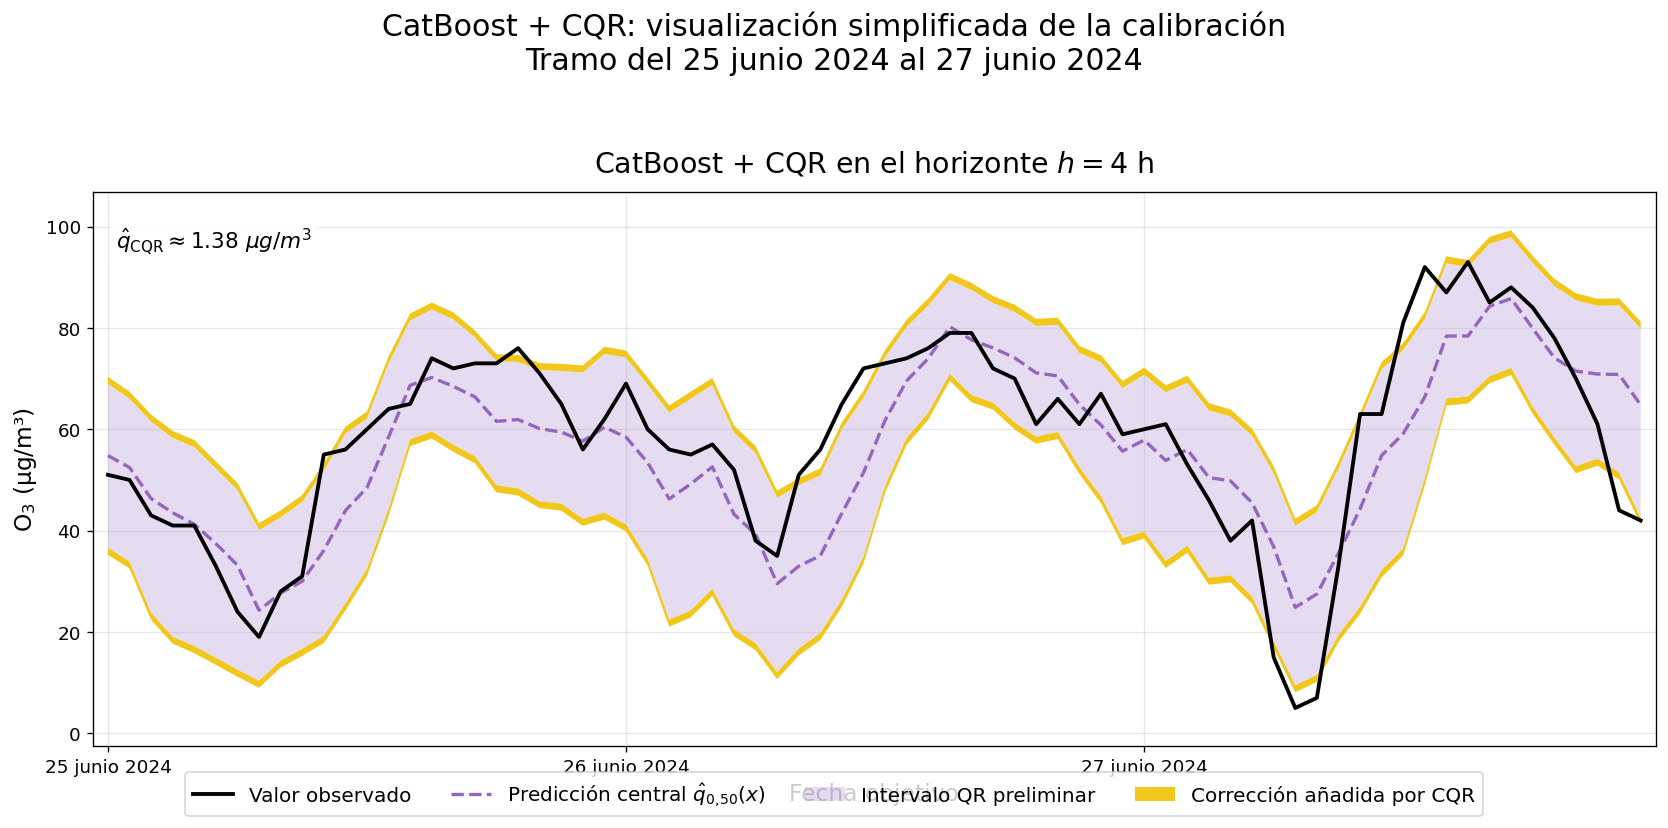

In [31]:
# ==============================================================================
# Figura: visualización simplificada del efecto de CQR en CatBoost
# - tres horizontes: h = 1, h = 4 y h = 24
# - ventana corta común
# - sin líneas de cuantiles ni bordes de intervalos
# - morado = intervalo QR preliminar
# - amarillo = corrección añadida por CQR
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

# ------------------------------------------------------------------
# Configuración
# ------------------------------------------------------------------
SELECTED_HORIZONS = [4]
N_DAYS_TO_SHOW = 3

# 0 = empezar al inicio del tramo maestro.
# 1 = empezar un día después, etc.
VISUAL_START_OFFSET_DAYS = 0

# Altura de cada panel
PANEL_HEIGHT = 7.0

# ------------------------------------------------------------------
# Comprobación de horizontes disponibles
# ------------------------------------------------------------------
missing_horizons = [
    horizon
    for horizon in SELECTED_HORIZONS
    if horizon not in catboost_visual_blocks_by_horizon
]

if missing_horizons:
    raise KeyError(
        f"Faltan bloques visuales para los horizontes {missing_horizons}. "
        f"Horizontes disponibles: {list(catboost_visual_blocks_by_horizon.keys())}"
    )

# ------------------------------------------------------------------
# Se define una ventana temporal común para todos los horizontes
# ------------------------------------------------------------------
horizon_start_times = []
horizon_end_times = []

for horizon in SELECTED_HORIZONS:
    block_h = catboost_visual_blocks_by_horizon[horizon].copy()
    block_h["target_timestamp"] = pd.to_datetime(block_h["target_timestamp"])

    horizon_start_times.append(block_h["target_timestamp"].min())
    horizon_end_times.append(block_h["target_timestamp"].max())

common_start_ts = max(horizon_start_times)
common_end_available_ts = min(horizon_end_times)

start_ts = common_start_ts + pd.Timedelta(days=VISUAL_START_OFFSET_DAYS)
end_ts = start_ts + pd.Timedelta(days=N_DAYS_TO_SHOW) - pd.Timedelta(hours=1)

if end_ts > common_end_available_ts:
    raise ValueError(
        f"La ventana solicitada termina en {end_ts}, pero el último timestamp común "
        f"disponible es {common_end_available_ts}. Reduce N_DAYS_TO_SHOW o "
        f"VISUAL_START_OFFSET_DAYS."
    )

expected_hours = N_DAYS_TO_SHOW * 24

visual_blocks_by_horizon = {}

for horizon in SELECTED_HORIZONS:
    block_h = catboost_visual_blocks_by_horizon[horizon].copy()
    block_h = block_h.sort_values("target_timestamp").reset_index(drop=True)
    block_h["target_timestamp"] = pd.to_datetime(block_h["target_timestamp"])

    block_h = block_h.loc[
        (block_h["target_timestamp"] >= start_ts)
        & (block_h["target_timestamp"] <= end_ts)
    ].copy()

    if len(block_h) != expected_hours:
        raise ValueError(
            f"El bloque para h={horizon} tiene {len(block_h)} observaciones, "
            f"pero se esperaban {expected_hours}. Revisa la continuidad del tramo."
        )

    visual_blocks_by_horizon[horizon] = block_h

print(
    "Tramo visual seleccionado:",
    start_ts,
    "→",
    end_ts,
    f"({expected_hours} horas)"
)

# ------------------------------------------------------------------
# Colores
# ------------------------------------------------------------------
observed_color = "black"
central_color = MODEL_REGISTRY[CATBOOST_MODEL_ID]["color"]   # color CatBoost
qr_band_color = "#8e63c7"     # morado
cqr_add_color = "#f1c40f"     # amarillo

# ------------------------------------------------------------------
# Rango vertical común para los tres paneles
# ------------------------------------------------------------------
y_values = pd.concat(
    [
        block_h[
            [
                "y_true",
                "central_pred",
                "prelim_lower",
                "prelim_upper",
                "calibrated_lower",
                "calibrated_upper",
            ]
        ].stack()
        for block_h in visual_blocks_by_horizon.values()
    ],
    axis=0,
).dropna()

y_min = y_values.min()
y_max = y_values.max()
y_margin = 0.08 * (y_max - y_min)

if y_margin == 0:
    y_margin = 1.0

common_ylim = (y_min - y_margin, y_max + y_margin)

# ------------------------------------------------------------------
# Funciones auxiliares para fechas en español
# ------------------------------------------------------------------
SPANISH_MONTH_ABBR = {
    1: "enero",
    2: "febrero",
    3: "marzo",
    4: "abril",
    5: "mayo",
    6: "junio",
    7: "julio",
    8: "agosto",
    9: "septiembre",
    10: "octubre",
    11: "noviembre",
    12: "diciembre",
}

def spanish_axis_date(x, pos=None):
    dt = mdates.num2date(x)
    return f"{dt.day:02d} {SPANISH_MONTH_ABBR[dt.month]} {dt.year}"

def format_spanish_date(ts):
    ts = pd.Timestamp(ts)
    return f"{ts.day:02d} {SPANISH_MONTH_ABBR[ts.month]} {ts.year}"

# ------------------------------------------------------------------
# Figura
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    len(SELECTED_HORIZONS),
    1,
    figsize=(14, PANEL_HEIGHT * len(SELECTED_HORIZONS)),
    sharex=True,
    sharey=True,
)

if len(SELECTED_HORIZONS) == 1:
    axes = [axes]

for ax, horizon in zip(axes, SELECTED_HORIZONS):
    block = visual_blocks_by_horizon[horizon]

    # ------------------------------------------------------------------
    # Corrección CQR
    # ------------------------------------------------------------------
    lower_delta = block["prelim_lower"] - block["calibrated_lower"]
    upper_delta = block["calibrated_upper"] - block["prelim_upper"]

    q_cqr = (lower_delta.median() + upper_delta.median()) / 2

    # --------------------------------------------------------------
    # 1) Intervalo QR preliminar (banda morada)
    # --------------------------------------------------------------
    ax.fill_between(
        block["target_timestamp"],
        block["prelim_lower"],
        block["prelim_upper"],
        color=qr_band_color,
        alpha=0.22,
        edgecolor="none",
        linewidth=0,
        zorder=1,
    )

    # --------------------------------------------------------------
    # 2) Corrección añadida por CQR (banda amarilla)
    # --------------------------------------------------------------
    ax.fill_between(
        block["target_timestamp"],
        block["calibrated_lower"],
        block["prelim_lower"],
        color=cqr_add_color,
        alpha=0.95,
        edgecolor="none",
        linewidth=0,
        zorder=2,
    )

    ax.fill_between(
        block["target_timestamp"],
        block["prelim_upper"],
        block["calibrated_upper"],
        color=cqr_add_color,
        alpha=0.95,
        edgecolor="none",
        linewidth=0,
        zorder=2,
    )

    # --------------------------------------------------------------
    # 3) Valor observado
    # --------------------------------------------------------------
    ax.plot(
        block["target_timestamp"],
        block["y_true"],
        color=observed_color,
        linewidth=2.3,
        zorder=5,
    )

    # --------------------------------------------------------------
    # 4) Predicción central
    # --------------------------------------------------------------
    ax.plot(
        block["target_timestamp"],
        block["central_pred"],
        color=central_color,
        linewidth=2.0,
        linestyle="--",
        zorder=4,
    )

    # --------------------------------------------------------------
    # Texto con la corrección aproximada
    # --------------------------------------------------------------
    ax.text(
        0.015,
        0.90,
        rf"$\hat{{q}}_{{\mathrm{{CQR}}}} \approx {q_cqr:.2f}$ $\mu g/m^3$",
        transform=ax.transAxes,
        fontsize=13,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
            pad=4,
        ),
    )

    # ------------------------------------------------------------------
    # Formato del panel
    # ------------------------------------------------------------------
    ax.set_title(
        rf"CatBoost + CQR en el horizonte $h={horizon}$ h",
        fontsize=17,
        pad=12,
    )

    ax.set_ylabel(r"$\mathrm{O}_3$ (µg/m³)", fontsize=14)
    ax.set_ylim(common_ylim)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=11)
    ax.margins(x=0.01, y=0.08)

axes[-1].set_xlabel("Fecha objetivo", fontsize=14)

# ------------------------------------------------------------------
# Formato de fechas
# ------------------------------------------------------------------
date_locator = mdates.DayLocator(interval=1)
date_formatter = FuncFormatter(spanish_axis_date)

for ax in axes:
    ax.xaxis.set_major_locator(date_locator)
    ax.xaxis.set_major_formatter(date_formatter)
    ax.tick_params(axis="x", rotation=0)
    plt.setp(ax.get_xticklabels(), ha="center")

# ------------------------------------------------------------------
# Leyenda debajo de la figura
# ------------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color=observed_color,
        linewidth=2.3,
        label="Valor observado",
    ),
    Line2D(
        [0], [0],
        color=central_color,
        linewidth=2.0,
        linestyle="--",
        label=r"Predicción central $\hat{q}_{0{,}50}(x)$",
    ),
    Patch(
        facecolor=qr_band_color,
        alpha=0.22,
        label="Intervalo QR preliminar",
    ),
    Patch(
        facecolor=cqr_add_color,
        alpha=0.95,
        label="Corrección añadida por CQR",
    ),
]

legend = fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncol=4,
    fontsize=12,
    frameon=True,
)

# ------------------------------------------------------------------
# Título general
# ------------------------------------------------------------------
fig.suptitle(
    "CatBoost + CQR: visualización simplificada de la calibración\n"
    f"Tramo del {format_spanish_date(start_ts)} al {format_spanish_date(end_ts)}",
    fontsize=18,
    y=0.985,
)

# ------------------------------------------------------------------
# Ajuste del espacio de la figura
# ------------------------------------------------------------------
fig.tight_layout(rect=(0, 0.07, 1, 0.94))
fig.subplots_adjust(hspace=0.30, bottom=0.11)

cqr_effect_zoom_path = (
    REPORTS_FIGURES_DIR / "fig_catboost_cqr_effect_simplified_h01_h04_h24.png"
)

fig.savefig(
    cqr_effect_zoom_path,
    dpi=300,
    bbox_inches="tight",
    bbox_extra_artists=(legend,),
)

print(f"Figura guardada en: {cqr_effect_zoom_path}")

plt.show()

In [32]:
for horizon in [1, 4, 24]:
    block_all = common_intervals.loc[
        (common_intervals["model"] == "catboost")
        & (common_intervals["horizon"] == horizon)
    ].copy()

    prelim_covered = (
        (block_all["y_true"] >= block_all["lower_prelim"])
        & (block_all["y_true"] <= block_all["upper_prelim"])
    )

    calibrated_covered = (
        (block_all["y_true"] >= block_all["lower"])
        & (block_all["y_true"] <= block_all["upper"])
    )

    prelim_width = (
        block_all["upper_prelim"] - block_all["lower_prelim"]
    ).mean()

    calibrated_width = (
        block_all["upper"] - block_all["lower"]
    ).mean()

    print(f"\nHorizonte h={horizon}")
    print(f"N observaciones comunes:     {len(block_all)}")
    print(f"Anchura preliminar media:    {prelim_width:.4f}")
    print(f"Anchura calibrada media:     {calibrated_width:.4f}")
    print(f"Cobertura preliminar global: {prelim_covered.mean():.4f}")
    print(f"Cobertura calibrada global:  {calibrated_covered.mean():.4f}")


Horizonte h=1
N observaciones comunes:     8265
Anchura preliminar media:    18.5719
Anchura calibrada media:     19.7592
Cobertura preliminar global: 0.7700
Cobertura calibrada global:  0.8017

Horizonte h=4
N observaciones comunes:     8265
Anchura preliminar media:    33.1324
Anchura calibrada media:     35.9022
Cobertura preliminar global: 0.7395
Cobertura calibrada global:  0.7898

Horizonte h=24
N observaciones comunes:     8265
Anchura preliminar media:    41.7363
Anchura calibrada media:     43.0097
Cobertura preliminar global: 0.7532
Cobertura calibrada global:  0.7792


In [33]:

# Comprobaciones finales
# ==============================================================================
assert not validation_intervals.empty, "No se han cargado los intervalos de validación."
assert not available_metrics_df.empty, "La tabla de métricas disponibles está vacía."
assert not common_metrics_df.empty, "La tabla de métricas comunes está vacía."
assert len(common_metrics_df) == len(MODEL_ORDER) * len(HORIZONS), "Faltan combinaciones modelo-horizonte en la comparación principal."
assert (common_metrics_df["n_samples"] > 0).all(), "Algún método carece de observaciones comunes."
assert (comparison_target_counts_df["n_common_targets"] > 0).all(), "Algún horizonte no tiene instantes comunes."

expected_figure_paths = [
    REPORTS_FIGURES_DIR / "fig_interval_metrics_validation_common.png",
    REPORTS_FIGURES_DIR / "fig_interval_tradeoff_validation_common.png",
    REPORTS_FIGURES_DIR / "fig_interval_improvement_vs_baseline_validation_common.png",
    REPORTS_FIGURES_DIR / f"fig_interval_zoom_best_vs_baseline_h{EXAMPLE_HORIZON:02d}.png",
    REPORTS_FIGURES_DIR / "fig_catboost_quantiles_prelim_h01_h04_h24.png",
    REPORTS_FIGURES_DIR / "fig_catboost_cqr_intervals_h01_h04_h24.png",
    REPORTS_FIGURES_DIR / "fig_catboost_cqr_effect_h04.png",
]
missing_figures = [path for path in expected_figure_paths if not path.exists()]
assert not missing_figures, f"Faltan figuras: {missing_figures}"

print("Comprobaciones finales superadas correctamente.")
print("- Se han comparado todos los métodos sobre validación 2024.")
print("- La comparación principal se ha construido sobre instantes objetivo comunes.")
print("- Se han guardado tablas comparativas y figuras para la memoria.")
print("- Queda preparado el material para la redacción de resultados de intervalos.")


Comprobaciones finales superadas correctamente.
- Se han comparado todos los métodos sobre validación 2024.
- La comparación principal se ha construido sobre instantes objetivo comunes.
- Se han guardado tablas comparativas y figuras para la memoria.
- Queda preparado el material para la redacción de resultados de intervalos.
